# Lab 2 - Task 1: Frequency-Based Baseline

Baseline con frequenze delle API call e Logistic Regression.

## Funzioni

**Checkpoint/cache.** Su Colab gli artefatti del Task 1 vengono salvati in `Google Drive/MyDrive/lab2/artifacts/task-1`.
Con `FORCE_RETRAIN = False`, se il modello esiste gia su Drive Optuna viene saltato e il modello viene ricaricato.


In [21]:
import json
import subprocess
import sys
from collections import Counter
from pathlib import Path
from urllib.request import urlretrieve

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [22]:
RANDOM_STATE = 42
RAW_BASE_URL = "https://raw.githubusercontent.com/MagicThunder02/lab2/main"
TRAIN_PATH = Path("train.json")
TEST_PATH = Path("test.json")
FIGURE_DIR = Path("figures/task-1")
FORCE_RETRAIN = False
USE_GOOGLE_DRIVE_ARTIFACTS = True
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/lab2")
LOCAL_ARTIFACT_DIR = Path("artifacts/task-1")


def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False


def get_artifact_dir():
    if USE_GOOGLE_DRIVE_ARTIFACTS and is_colab():
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        artifact_dir = DRIVE_PROJECT_DIR / "artifacts/task-1"
    else:
        artifact_dir = LOCAL_ARTIFACT_DIR
    artifact_dir.mkdir(parents=True, exist_ok=True)
    return artifact_dir


ARTIFACT_DIR = get_artifact_dir()
print(f"Task 1 artifacts directory: {ARTIFACT_DIR}")


def raw_url_for(path):
    return f"{RAW_BASE_URL}/{Path(path).as_posix()}"


def try_download_from_github(path):
    path = Path(path)
    if path.exists():
        return True
    url = raw_url_for(path)
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading {path.as_posix()} from {url}")
        urlretrieve(url, path)
        return True
    except Exception:
        if path.exists():
            path.unlink()
        return False


def ensure_data_file(path):
    path = Path(path)
    if path.exists() or try_download_from_github(path):
        return path

    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f"{path.name} not found locally and could not be downloaded from {raw_url_for(path)}."
        ) from exc

    print(f"Could not download {path.name}. Upload it manually in Colab.")
    uploaded = files.upload()
    if path.name not in uploaded:
        raise FileNotFoundError(f"Uploaded files do not include {path.name}.")
    return path


def load_dataset(path):
    path = ensure_data_file(path)
    with path.open(encoding="utf-8") as f:
        data = json.load(f)
    X = [row["api_call_sequence"] for row in data]
    y = np.array([row["is_malware"] for row in data], dtype=int)
    return X, y


def vocabulary(sequences):
    return set(api for seq in sequences for api in seq)


def sequence_length_summary(sequences):
    lengths = np.array([len(seq) for seq in sequences])
    return {
        "n_samples": len(sequences),
        "min_len": int(lengths.min()),
        "median_len": float(np.median(lengths)),
        "mean_len": float(lengths.mean()),
        "max_len": int(lengths.max()),
    }


def dataset_overview(X_train, y_train, X_test, y_test):
    rows = []
    for split, X, y in [("train", X_train, y_train), ("test", X_test, y_test)]:
        label_counts = Counter(y)
        row = sequence_length_summary(X)
        row.update({
            "split": split,
            "goodware_0": label_counts.get(0, 0),
            "malware_1": label_counts.get(1, 0),
            "malware_%": 100 * label_counts.get(1, 0) / len(y),
            "unique_api_calls": len(vocabulary(X)),
        })
        rows.append(row)
    cols = ["split", "n_samples", "goodware_0", "malware_1", "malware_%", "min_len", "median_len", "mean_len", "max_len", "unique_api_calls"]
    return pd.DataFrame(rows)[cols].round(3)


def vocabulary_report(X_train, X_test):
    train_vocab = vocabulary(X_train)
    test_vocab = vocabulary(X_test)
    only_test = sorted(test_vocab - train_vocab)
    only_train = sorted(train_vocab - test_vocab)
    summary = pd.DataFrame([{
        "train_vocab_size": len(train_vocab),
        "test_vocab_size": len(test_vocab),
        "intersection": len(train_vocab & test_vocab),
        "only_in_test_count": len(only_test),
        "only_in_train_count": len(only_train),
    }])
    return summary, only_test, only_train


def sequences_to_text(sequences):
    return [" ".join(seq) for seq in sequences]


def build_frequency_matrices(X_train, X_test):
    train_vocab = sorted(vocabulary(X_train))
    vectorizer = CountVectorizer(
        analyzer="word",
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        vocabulary=train_vocab,
        lowercase=False,
    )
    X_train_freq = vectorizer.fit_transform(sequences_to_text(X_train))
    X_test_freq = vectorizer.transform(sequences_to_text(X_test))
    feature_names = vectorizer.get_feature_names_out()
    return X_train_freq, X_test_freq, feature_names, vectorizer


def sparsity_report(X_train_freq, X_test_freq):
    rows = []
    for split, matrix in [("train", X_train_freq), ("test", X_test_freq)]:
        nnz_per_row = matrix.getnnz(axis=1)
        n_features = matrix.shape[1]
        rows.append({
            "split": split,
            "shape": f"{matrix.shape[0]} x {matrix.shape[1]}",
            "avg_non_zero_per_row": nnz_per_row.mean(),
            "min_non_zero": nnz_per_row.min(),
            "median_non_zero": np.median(nnz_per_row),
            "max_non_zero": nnz_per_row.max(),
            "non_zero_ratio": nnz_per_row.mean() / n_features,
            "zero_ratio": 1 - (nnz_per_row.mean() / n_features),
        })
    return pd.DataFrame(rows).round(4)


def train_logistic_regression(X_train_freq, y_train, n_trials=30):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        params = {
            "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
            "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
            "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        }
        model = LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
            **params,
        )
        scores = cross_val_score(model, X_train_freq, y_train, scoring="f1_macro", cv=cv, n_jobs=-1)
        return scores.mean()

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params
    model = LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
        **best_params,
    )
    model.fit(X_train_freq, y_train)

    trials = study.trials_dataframe(attrs=("number", "value", "params", "state"))
    trials = trials.sort_values("value", ascending=False).reset_index(drop=True)
    return model, best_params, study.best_value, trials


def artifact_paths(artifact_dir=ARTIFACT_DIR):
    artifact_dir = Path(artifact_dir)
    return {
        "model": artifact_dir / "logistic_regression.joblib",
        "trials": artifact_dir / "optuna_trials.csv",
        "summary": artifact_dir / "training_summary.json",
        "results": artifact_dir / "results.json",
    }


def save_training_artifacts(model, best_params, best_cv_score, optuna_trials, artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    Path(artifact_dir).mkdir(parents=True, exist_ok=True)
    joblib.dump(model, paths["model"])
    optuna_trials.to_csv(paths["trials"], index=False)
    summary = {
        "best_params": best_params,
        "best_cv_score": float(best_cv_score),
        "model_type": "LogisticRegression",
        "cv": "StratifiedKFold(n_splits=5, shuffle=True)",
        "scoring": "f1_macro",
    }
    with paths["summary"].open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)


def load_training_artifacts(artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    required = [paths["model"], paths["trials"], paths["summary"]]
    for path in required:
        if not path.exists():
            return None

    model = joblib.load(paths["model"])
    optuna_trials = pd.read_csv(paths["trials"])
    with paths["summary"].open(encoding="utf-8") as f:
        summary = json.load(f)
    return model, summary["best_params"], summary["best_cv_score"], optuna_trials


def train_or_load_logistic_regression(X_train_freq, y_train, force_retrain=FORCE_RETRAIN, n_trials=30):
    if not force_retrain:
        cached = load_training_artifacts()
        if cached is not None:
            print("Loaded Logistic Regression artifacts from cache.")
            return cached

    print("Training Logistic Regression with Optuna.")
    model, best_params, best_cv_score, optuna_trials = train_logistic_regression(
        X_train_freq, y_train, n_trials=n_trials
    )
    save_training_artifacts(model, best_params, best_cv_score, optuna_trials)
    return model, best_params, best_cv_score, optuna_trials


def evaluate_classifier(model, X_test_freq, y_test):
    y_pred = model.predict(X_test_freq)
    y_score = model.predict_proba(X_test_freq)[:, 1]
    metrics = pd.DataFrame([{
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_goodware_0": f1_score(y_test, y_pred, pos_label=0, zero_division=0),
        "f1_malware_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
    }]).round(4)
    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=[0, 1]),
        index=["true_goodware_0", "true_malware_1"],
        columns=["pred_goodware_0", "pred_malware_1"],
    )
    report = pd.DataFrame(classification_report(y_test, y_pred, labels=[0, 1], target_names=["goodware_0", "malware_1"], output_dict=True, zero_division=0)).T.round(4)
    return metrics, cm, report


def save_evaluation_artifacts(metrics, cm, report, artifact_dir=ARTIFACT_DIR):
    paths = artifact_paths(artifact_dir)
    Path(artifact_dir).mkdir(parents=True, exist_ok=True)
    results = {
        "metrics": metrics.to_dict(orient="records"),
        "confusion_matrix": cm.to_dict(),
        "classification_report": report.to_dict(),
    }
    with paths["results"].open("w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)


def api_presence_in_test_only(X_test, only_test_apis):
    counts = Counter(api for seq in X_test for api in seq if api in only_test_apis)
    rows = [{"api_call": api, "test_frequency": counts[api]} for api in only_test_apis]
    return pd.DataFrame(rows)


def save_confusion_matrix_plot(cm, figure_dir=FIGURE_DIR, filename="confusion_matrix", title="Logistic Regression Confusion Matrix"):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    matrix = cm.to_numpy()
    labels = ["Goodware (0)", "Malware (1)"]
    fig, ax = plt.subplots(figsize=(5.2, 4.4))
    image = ax.imshow(matrix, interpolation="nearest", cmap="Blues")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        ylabel="True label",
        xlabel="Predicted label",
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right", rotation_mode="anchor")
    threshold = matrix.max() / 2
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(
                j,
                i,
                f"{matrix[i, j]:d}",
                ha="center",
                va="center",
                color="white" if matrix[i, j] > threshold else "black",
                fontsize=12,
            )
    fig.tight_layout()
    fig.savefig(figure_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    return fig


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Task 1 artifacts directory: /content/drive/MyDrive/lab2/artifacts/task-1


## Output per rispondere al Task 1

In [23]:
X_train, y_train = load_dataset(TRAIN_PATH)
X_test, y_test = load_dataset(TEST_PATH)

overview = dataset_overview(X_train, y_train, X_test, y_test)
display(overview)

,split,n_samples,goodware_0,malware_1,malware_%,min_len,median_len,mean_len,max_len,unique_api_calls
0,train,16325,611,15714,96.257,60,75.0,75.031,90,258
1,test,6505,243,6262,96.264,70,87.0,86.331,100,232


In [24]:
vocab_summary, only_test_apis, only_train_apis = vocabulary_report(X_train, X_test)
display(vocab_summary)
print("API call presenti solo nel test:")
print(only_test_apis)
display(api_presence_in_test_only(X_test, only_test_apis))

,train_vocab_size,test_vocab_size,intersection,only_in_test_count,only_in_train_count
0,258,232,229,3,29


API call presenti solo nel test:
['ControlService', 'NtDeleteKey', 'WSASocketA']


,api_call,test_frequency
0,ControlService,1
1,NtDeleteKey,1
2,WSASocketA,1


In [25]:
X_train_freq, X_test_freq, feature_names, vectorizer = build_frequency_matrices(X_train, X_test)
print(f"Feature usate: vocabolario del train ({len(feature_names)} colonne).")
print("Le API presenti solo nel test vengono ignorate perch? non hanno una colonna appresa dal train.")
display(sparsity_report(X_train_freq, X_test_freq))

Feature usate: vocabolario del train (258 colonne).
Le API presenti solo nel test vengono ignorate perch? non hanno una colonna appresa dal train.


,split,shape,avg_non_zero_per_row,min_non_zero,median_non_zero,max_non_zero,non_zero_ratio,zero_ratio
0,train,16325 x 258,21.9471,2,22.0,41,0.0851,0.9149
1,test,6505 x 258,24.2782,2,26.0,45,0.0941,0.9059


In [26]:
model, best_params, best_cv_score, optuna_trials = train_or_load_logistic_regression(X_train_freq, y_train)
print("Migliori iperparametri:", best_params)
print(f"Miglior F1 macro medio con Optuna + 5-fold CV: {best_cv_score:.4f}")
display(optuna_trials.head(10).round(4))

Loaded Logistic Regression artifacts from cache.
Migliori iperparametri: {'C': 41.318506569741785, 'class_weight': None, 'penalty': 'l2'}
Miglior F1 macro medio con Optuna + 5-fold CV: 0.7180


,number,value,params_C,params_class_weight,params_penalty,state
0,22,0.7180,41.3185,NaN,l2,COMPLETE
1,12,0.7175,85.5240,NaN,l2,COMPLETE
2,25,0.7174,4.5520,NaN,l2,COMPLETE
3,16,0.7173,32.9516,NaN,l2,COMPLETE
4,23,0.7173,27.7671,NaN,l2,COMPLETE
5,24,0.7170,10.8431,NaN,l2,COMPLETE
6,10,0.7170,69.9642,NaN,l2,COMPLETE
7,13,0.7165,97.3840,NaN,l2,COMPLETE
8,21,0.7165,98.0968,NaN,l2,COMPLETE
9,18,0.7165,22.9692,NaN,l2,COMPLETE


Metriche finali sul test set


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1,roc_auc
0,0.9688,0.6654,0.818,0.6654,0.7154,0.4469,0.9839,0.9028


Matrice di confusione


,pred_goodware_0,pred_malware_1
true_goodware_0,82,161
true_malware_1,42,6220


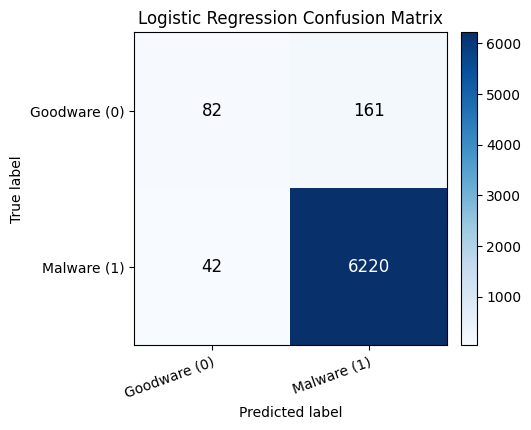

Classification report


,precision,recall,f1-score,support
goodware_0,0.6613,0.3374,0.4469,243.0000
malware_1,0.9748,0.9933,0.9839,6262.0000
accuracy,0.9688,0.9688,0.9688,0.9688
macro avg,0.8180,0.6654,0.7154,6505.0000
weighted avg,0.9631,0.9688,0.9639,6505.0000


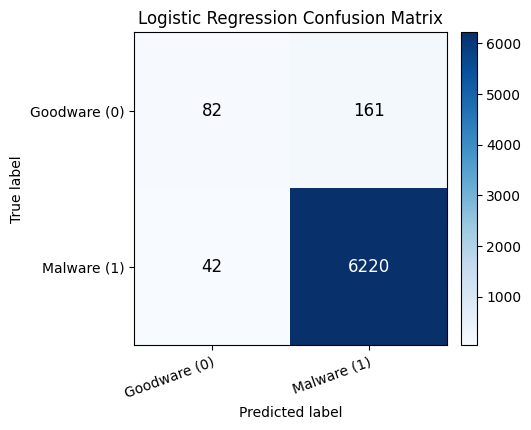

In [27]:
metrics, cm, report = evaluate_classifier(model, X_test_freq, y_test)
save_evaluation_artifacts(metrics, cm, report)
print("Metriche finali sul test set")
display(metrics)
print("Matrice di confusione")
display(cm)
fig = save_confusion_matrix_plot(cm)
display(fig)
print("Classification report")
display(report)

In [28]:
answers = [
    ["Vocabolario", f"Train: {len(vocabulary(X_train))} API uniche. Test: {len(vocabulary(X_test))} API uniche. Solo nel test: {len(only_test_apis)} ({', '.join(only_test_apis)})."],
    ["Costruzione test dataframe", "Uso sempre il vocabolario del train per train e test. Le API solo nel test sono out-of-vocabulary e vengono ignorate, evitando leakage dal test."],
    ["Sparsita", "Ogni riga ha 258 feature. La tabella sopra mostra gli elementi non-zero medi e il rapporto rispetto al numero di feature."],
    ["Ordine", "No. Il dataframe frequency-based conserva solo quante volte compare ogni API call, non la posizione: non sappiamo piu quale API sia arrivata prima."],
    ["Classifier", f"Logistic Regression. Ho scelto C, class_weight e penalty con Optuna + 5-fold CV sul train, ottimizzando F1 macro. Parametri finali: {best_params}."],
    ["Qualita finale", "La performance e buona se accuracy/F1 malware sono alti, ma va letta insieme a balanced accuracy e F1 goodware perche il dataset e fortemente sbilanciato verso malware."],
]
display(pd.DataFrame(answers, columns=["Domanda", "Risposta sintetica"]))

,Domanda,Risposta sintetica
0,Vocabolario,Train: 258 API uniche. Test: 232 API uniche. S...
1,Costruzione test dataframe,Uso sempre il vocabolario del train per train ...
2,Sparsita,Ogni riga ha 258 feature. La tabella sopra mos...
3,Ordine,No. Il dataframe frequency-based conserva solo...
4,Classifier,"Logistic Regression. Ho scelto C, class_weight..."
5,Qualita finale,La performance e buona se accuracy/F1 malware ...


# Task 2: Feed Forward Neural Network

FFNN su sequenze a lunghezza fissa, con due rappresentazioni: ID sequenziali numerici e embedding learnable.

## Funzioni Task 2

**Checkpoint/cache.** Su Colab gli artefatti del Task 2 vengono salvati in `Google Drive/MyDrive/lab2/artifacts/task-2`. Con `FORCE_RETRAIN = False`, i modelli gia salvati vengono ricaricati e il training viene saltato.

In [29]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError("PyTorch is required for Task 2. On Colab, set Runtime > Change runtime type > GPU and rerun.") from exc

from sklearn.model_selection import train_test_split

TASK2_FIGURE_DIR = Path("figures/task-2")
TASK2_LOCAL_ARTIFACT_DIR = Path("artifacts/task-2")


def get_task_artifact_dir(task_name):
    if USE_GOOGLE_DRIVE_ARTIFACTS and is_colab():
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        artifact_dir = DRIVE_PROJECT_DIR / f"artifacts/{task_name}"
    else:
        artifact_dir = Path("artifacts") / task_name
    artifact_dir.mkdir(parents=True, exist_ok=True)
    return artifact_dir


TASK2_ARTIFACT_DIR = get_task_artifact_dir("task-2")
print(f"Task 2 artifacts directory: {TASK2_ARTIFACT_DIR}")


def set_torch_seed(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sequence_length_distribution_report(X_train, X_test):
    rows = []
    for split, X in [("train", X_train), ("test", X_test)]:
        lengths = np.array([len(seq) for seq in X])
        rows.append({
            "split": split,
            "n_samples": len(X),
            "min": int(lengths.min()),
            "p25": float(np.percentile(lengths, 25)),
            "median": float(np.median(lengths)),
            "mean": float(lengths.mean()),
            "p75": float(np.percentile(lengths, 75)),
            "p95": float(np.percentile(lengths, 95)),
            "max": int(lengths.max()),
        })
    return pd.DataFrame(rows).round(3)


def save_sequence_length_plot(X_train, X_test, figure_dir=TASK2_FIGURE_DIR):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    train_lengths = [len(seq) for seq in X_train]
    test_lengths = [len(seq) for seq in X_test]
    fig, ax = plt.subplots(figsize=(6.2, 4.0))
    bins = np.arange(min(train_lengths + test_lengths), max(train_lengths + test_lengths) + 2) - 0.5
    ax.hist(train_lengths, bins=bins, alpha=0.65, label="Train", density=True)
    ax.hist(test_lengths, bins=bins, alpha=0.65, label="Test", density=True)
    ax.set_xlabel("API calls per sequence")
    ax.set_ylabel("Density")
    ax.set_title("Sequence Length Distribution")
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / "sequence_lengths.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / "sequence_lengths.png", dpi=300, bbox_inches="tight")
    return fig


def estimate_fixed_sequence_length(X_train):
    return max(len(seq) for seq in X_train)


def build_api_id_mapping(X_train):
    api_to_id = {"<PAD>": 0, "<UNK>": 1}
    for api in sorted(vocabulary(X_train)):
        api_to_id[api] = len(api_to_id)
    id_to_api = {idx: api for api, idx in api_to_id.items()}
    return api_to_id, id_to_api


def encode_padded_sequences(sequences, api_to_id, fixed_length):
    encoded = np.zeros((len(sequences), fixed_length), dtype=np.int64)
    stats = {
        "samples": len(sequences),
        "fixed_length": fixed_length,
        "truncated_sequences": 0,
        "truncated_api_calls": 0,
        "unknown_api_calls": 0,
    }
    unk_id = api_to_id["<UNK>"]
    for row, seq in enumerate(sequences):
        if len(seq) > fixed_length:
            stats["truncated_sequences"] += 1
            stats["truncated_api_calls"] += len(seq) - fixed_length
        for col, api in enumerate(seq[:fixed_length]):
            api_id = api_to_id.get(api, unk_id)
            if api_id == unk_id:
                stats["unknown_api_calls"] += 1
            encoded[row, col] = api_id
    return encoded, stats


def preprocessing_report(train_stats, test_stats, vocab_size):
    rows = []
    for split, stats in [("train", train_stats), ("test", test_stats)]:
        row = dict(stats)
        row["split"] = split
        row["vocab_size_including_pad_unk"] = vocab_size
        rows.append(row)
    cols = ["split", "samples", "fixed_length", "vocab_size_including_pad_unk", "truncated_sequences", "truncated_api_calls", "unknown_api_calls"]
    return pd.DataFrame(rows)[cols]


def make_ffnn_train_val_split(X_encoded, y, val_size=0.15):
    idx_train, idx_val = train_test_split(
        np.arange(len(y)), test_size=val_size, stratify=y, random_state=RANDOM_STATE
    )
    return X_encoded[idx_train], X_encoded[idx_val], y[idx_train], y[idx_val]


def class_weights_from_labels(y):
    counts = np.bincount(y, minlength=2).astype(np.float32)
    weights = counts.sum() / (2.0 * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32)


def make_loader(X, y, batch_size, model_kind, shuffle=False):
    if model_kind == "ids":
        max_id = max(float(X.max()), 1.0)
        X_tensor = torch.tensor(X / max_id, dtype=torch.float32)
    else:
        X_tensor = torch.tensor(X, dtype=torch.long)
    y_tensor = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


class SequentialIdFFNN(nn.Module):
    def __init__(self, fixed_length, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(fixed_length, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2),
        )

    def forward(self, x):
        return self.net(x)


class EmbeddingFFNN(nn.Module):
    def __init__(self, vocab_size, fixed_length, embedding_dim=16, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.net = nn.Sequential(
            nn.Linear(fixed_length * embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2),
        )

    def forward(self, x):
        embedded = self.embedding(x)
        return self.net(embedded.flatten(start_dim=1))


def build_ffnn_model(model_kind, config):
    if model_kind == "ids":
        return SequentialIdFFNN(
            fixed_length=config["fixed_length"],
            hidden_dim=config["hidden_dim"],
            dropout=config["dropout"],
        )
    if model_kind == "embedding":
        return EmbeddingFFNN(
            vocab_size=config["vocab_size"],
            fixed_length=config["fixed_length"],
            embedding_dim=config["embedding_dim"],
            hidden_dim=config["hidden_dim"],
            dropout=config["dropout"],
        )
    raise ValueError(f"Unknown model_kind: {model_kind}")


def run_training_loop(model, train_loader, val_loader, y_train_split, lr, weight_decay, max_epochs=25, patience=5, device=None):
    device = device or get_device()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_train_split).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _, _ = evaluate_torch_classifier(model, val_loader, device=device)
        val_f1 = float(val_metrics.loc[0, "f1_macro"])
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_f1_macro": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val_f1


def evaluate_torch_classifier(model, data_loader, device=None):
    device = device or get_device()
    model = model.to(device)
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
            y_score.extend(probs)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)
    metrics = pd.DataFrame([{
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_goodware_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_malware_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }]).round(4)
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=[0, 1]),
        index=["true_goodware_0", "true_malware_1"],
        columns=["pred_goodware_0", "pred_malware_1"],
    )
    report = pd.DataFrame(classification_report(y_true, y_pred, labels=[0, 1], target_names=["goodware_0", "malware_1"], output_dict=True, zero_division=0)).T.round(4)
    return metrics, cm, report


def task2_artifact_paths(model_kind, artifact_dir=TASK2_ARTIFACT_DIR):
    root = Path(artifact_dir) / model_kind
    return {
        "root": root,
        "checkpoint": root / "best_model.pt",
        "trials": root / "optuna_trials.csv",
        "history": root / "history.csv",
        "summary": root / "summary.json",
        "results": root / "results.json",
    }


def safe_torch_load(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def save_task2_artifacts(model_kind, model, config, best_params, best_cv_score, trials, history, metrics=None, cm=None, report=None):
    paths = task2_artifact_paths(model_kind)
    paths["root"].mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": model.state_dict(), "config": config}, paths["checkpoint"])
    trials.to_csv(paths["trials"], index=False)
    history.to_csv(paths["history"], index=False)
    summary = {"model_kind": model_kind, "config": config, "best_params": best_params, "best_cv_score": float(best_cv_score)}
    with paths["summary"].open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    if metrics is not None:
        results = {"metrics": metrics.to_dict(orient="records"), "confusion_matrix": cm.to_dict(), "classification_report": report.to_dict()}
        with paths["results"].open("w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)


def load_task2_artifacts(model_kind, device=None):
    device = device or get_device()
    paths = task2_artifact_paths(model_kind)
    required = [paths["checkpoint"], paths["trials"], paths["history"], paths["summary"]]
    if not all(path.exists() for path in required):
        return None
    checkpoint = safe_torch_load(paths["checkpoint"], device)
    with paths["summary"].open(encoding="utf-8") as f:
        summary = json.load(f)
    model = build_ffnn_model(model_kind, checkpoint["config"])
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    trials = pd.read_csv(paths["trials"])
    history = pd.read_csv(paths["history"])
    return model, summary["config"], summary["best_params"], summary["best_cv_score"], trials, history


def train_ffnn_with_optuna(model_kind, X_train_ids, y_train, fixed_length, vocab_size, n_trials=15, max_epochs=20):
    set_torch_seed()
    device = get_device()
    X_tr, X_val, y_tr, y_val = make_ffnn_train_val_split(X_train_ids, y_train)

    def objective(trial):
        params = {
            "hidden_dim": trial.suggest_categorical("hidden_dim", [64, 128, 256]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [128, 256, 512]),
        }
        config = {"fixed_length": fixed_length, "vocab_size": vocab_size, "hidden_dim": params["hidden_dim"], "dropout": params["dropout"]}
        if model_kind == "embedding":
            config["embedding_dim"] = trial.suggest_categorical("embedding_dim", [8, 16, 32])
        model = build_ffnn_model(model_kind, config)
        train_loader = make_loader(X_tr, y_tr, params["batch_size"], model_kind, shuffle=True)
        val_loader = make_loader(X_val, y_val, params["batch_size"], model_kind)
        _, _, best_val_f1 = run_training_loop(
            model, train_loader, val_loader, y_tr, params["lr"], params["weight_decay"], max_epochs=max_epochs, patience=4, device=device
        )
        return best_val_f1

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params

    config = {"fixed_length": fixed_length, "vocab_size": vocab_size, "hidden_dim": best_params["hidden_dim"], "dropout": best_params["dropout"]}
    if model_kind == "embedding":
        config["embedding_dim"] = best_params["embedding_dim"]
    final_model = build_ffnn_model(model_kind, config)
    train_loader = make_loader(X_tr, y_tr, best_params["batch_size"], model_kind, shuffle=True)
    val_loader = make_loader(X_val, y_val, best_params["batch_size"], model_kind)
    final_model, history, best_val_f1 = run_training_loop(
        final_model, train_loader, val_loader, y_tr, best_params["lr"], best_params["weight_decay"], max_epochs=max_epochs, patience=5, device=device
    )
    trials = study.trials_dataframe(attrs=("number", "value", "params", "state")).sort_values("value", ascending=False).reset_index(drop=True)
    return final_model, config, best_params, best_val_f1, trials, history


def train_or_load_ffnn(model_kind, X_train_ids, y_train, fixed_length, vocab_size, force_retrain=FORCE_RETRAIN, n_trials=15, max_epochs=20):
    if not force_retrain:
        cached = load_task2_artifacts(model_kind)
        if cached is not None:
            print(f"Loaded {model_kind} FFNN artifacts from cache.")
            return cached
    print(f"Training {model_kind} FFNN with Optuna on {get_device()}.")
    model, config, best_params, best_score, trials, history = train_ffnn_with_optuna(
        model_kind, X_train_ids, y_train, fixed_length, vocab_size, n_trials=n_trials, max_epochs=max_epochs
    )
    save_task2_artifacts(model_kind, model, config, best_params, best_score, trials, history)
    return model, config, best_params, best_score, trials, history


def save_task2_confusion_matrix_plot(cm, model_label, filename, figure_dir=TASK2_FIGURE_DIR):
    return save_confusion_matrix_plot(cm, figure_dir=figure_dir, filename=filename, title=f"{model_label} Confusion Matrix")


def save_training_curve_plot(history, model_label, filename, figure_dir=TASK2_FIGURE_DIR):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(5.8, 3.8))
    ax.plot(history["epoch"], history["val_f1_macro"], marker="o", label="Validation F1 macro")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1 macro")
    ax.set_title(f"{model_label} Validation Curve")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(figure_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    return fig

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Task 2 artifacts directory: /content/drive/MyDrive/lab2/artifacts/task-2


## Output per rispondere al Task 2

,split,n_samples,min,p25,median,mean,p75,p95,max
0,train,16325,60,67.0,75.0,75.031,83.0,89.0,90
1,test,6505,70,79.0,87.0,86.331,94.0,99.0,100


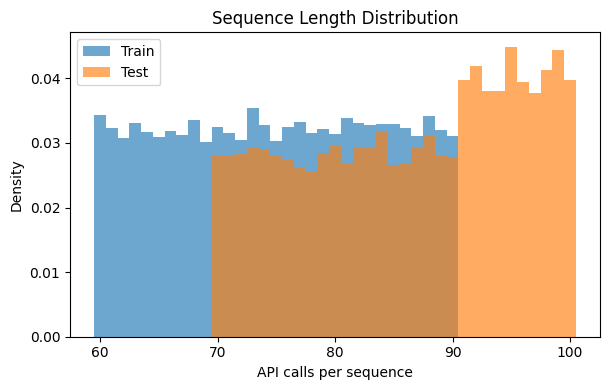

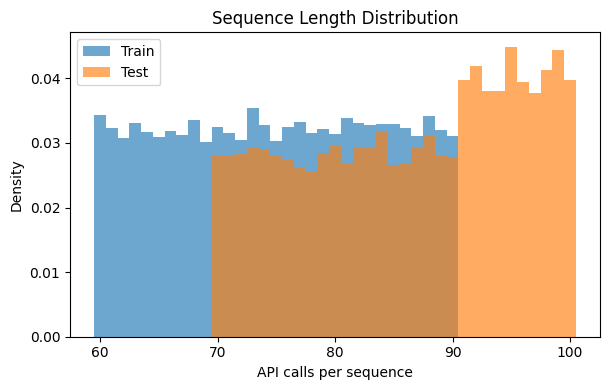

In [30]:
length_report = sequence_length_distribution_report(X_train, X_test)
display(length_report)
fig = save_sequence_length_plot(X_train, X_test)
display(fig)

In [31]:
fixed_length = estimate_fixed_sequence_length(X_train)
api_to_id, id_to_api = build_api_id_mapping(X_train)
X_train_ids, train_pad_stats = encode_padded_sequences(X_train, api_to_id, fixed_length)
X_test_ids, test_pad_stats = encode_padded_sequences(X_test, api_to_id, fixed_length)
preprocess_summary = preprocessing_report(train_pad_stats, test_pad_stats, len(api_to_id))
print(f"Fixed length stimata dal train: {fixed_length}")
print(f"Vocabulary size inclusi PAD/UNK: {len(api_to_id)}")
display(preprocess_summary)

Fixed length stimata dal train: 90
Vocabulary size inclusi PAD/UNK: 260


,split,samples,fixed_length,vocab_size_including_pad_unk,truncated_sequences,truncated_api_calls,unknown_api_calls
0,train,16325,90,260,0,0,0
1,test,6505,90,260,2639,14601,3


Loaded ids FFNN artifacts from cache.
Sequential-ID FFNN best params: {'hidden_dim': 256, 'dropout': 0.06974693032602092, 'lr': 0.00027010527749605503, 'weight_decay': 2.9204338471814107e-05, 'batch_size': 256}
Sequential-ID FFNN best validation F1 macro: 0.5403


,number,value,params_batch_size,params_dropout,params_hidden_dim,params_lr,params_weight_decay,state
0,2,0.5396,256,0.0697,256,0.0003,0.0000,COMPLETE
1,14,0.5352,128,0.4977,64,0.0004,0.0005,COMPLETE
2,8,0.5329,512,0.3645,128,0.0014,0.0000,COMPLETE
3,6,0.5256,512,0.0980,128,0.0001,0.0000,COMPLETE
4,10,0.5233,128,0.0030,256,0.0006,0.0002,COMPLETE
5,3,0.5187,256,0.3038,128,0.0002,0.0000,COMPLETE
6,11,0.5185,512,0.4828,128,0.0025,0.0000,COMPLETE
7,13,0.5178,512,0.1766,128,0.0007,0.0001,COMPLETE
8,9,0.5125,256,0.1555,64,0.0003,0.0008,COMPLETE
9,7,0.5123,128,0.0705,256,0.0015,0.0000,COMPLETE


,epoch,train_loss,val_f1_macro
2,3,0.6601,0.4308
3,4,0.6445,0.4669
4,5,0.6345,0.4564
5,6,0.6257,0.3070
6,7,0.6109,0.4577


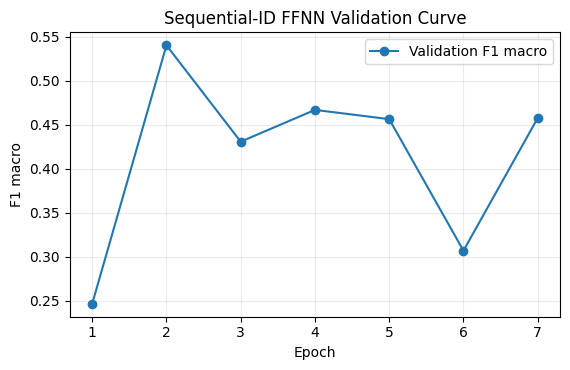

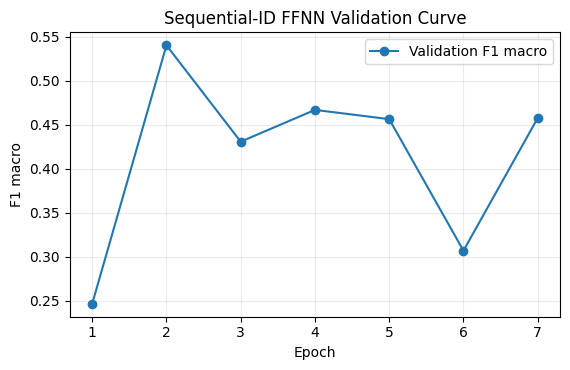

In [32]:
ids_model, ids_config, ids_best_params, ids_best_score, ids_trials, ids_history = train_or_load_ffnn(
    "ids", X_train_ids, y_train, fixed_length, len(api_to_id), n_trials=15, max_epochs=20
)
print("Sequential-ID FFNN best params:", ids_best_params)
print(f"Sequential-ID FFNN best validation F1 macro: {ids_best_score:.4f}")
display(ids_trials.head(10).round(4))
display(ids_history.tail().round(4))
fig = save_training_curve_plot(ids_history, "Sequential-ID FFNN", "ids_training_curve")
display(fig)

Sequential-ID FFNN test metrics


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1,roc_auc
0,0.9397,0.5138,0.519,0.5138,0.5155,0.0622,0.9689,0.5618


Sequential-ID FFNN confusion matrix


,pred_goodware_0,pred_malware_1
true_goodware_0,13,230
true_malware_1,162,6100


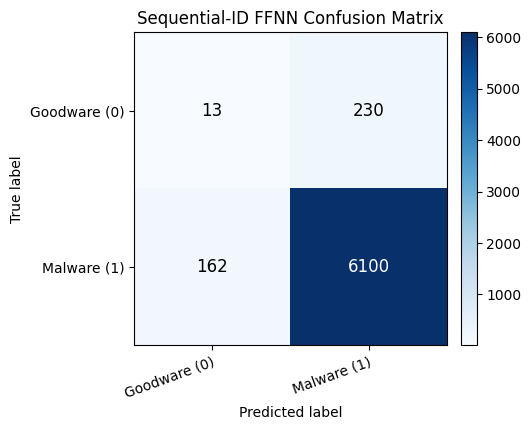

Sequential-ID FFNN classification report


,precision,recall,f1-score,support
goodware_0,0.0743,0.0535,0.0622,243.0000
malware_1,0.9637,0.9741,0.9689,6262.0000
accuracy,0.9397,0.9397,0.9397,0.9397
macro avg,0.5190,0.5138,0.5155,6505.0000
weighted avg,0.9304,0.9397,0.9350,6505.0000


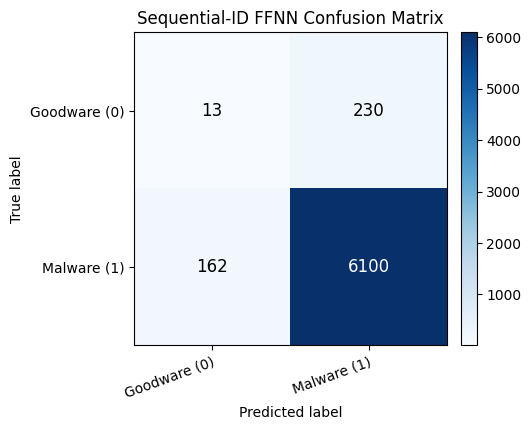

In [33]:
ids_test_loader = make_loader(X_test_ids, y_test, ids_best_params["batch_size"], "ids")
ids_metrics, ids_cm, ids_report = evaluate_torch_classifier(ids_model, ids_test_loader)
save_task2_artifacts("ids", ids_model, ids_config, ids_best_params, ids_best_score, ids_trials, ids_history, ids_metrics, ids_cm, ids_report)
print("Sequential-ID FFNN test metrics")
display(ids_metrics)
print("Sequential-ID FFNN confusion matrix")
display(ids_cm)
fig = save_task2_confusion_matrix_plot(ids_cm, "Sequential-ID FFNN", "ids_confusion_matrix")
display(fig)
print("Sequential-ID FFNN classification report")
display(ids_report)

Loaded embedding FFNN artifacts from cache.
Embedding FFNN best params: {'hidden_dim': 256, 'dropout': 0.08061064362700221, 'lr': 0.0023619797107806506, 'weight_decay': 0.0017079750342958238, 'batch_size': 256, 'embedding_dim': 16}
Embedding FFNN best validation F1 macro: 0.6838


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_weight_decay,state
0,9,0.7027,256,0.0806,16,256,0.0024,0.0017,COMPLETE
1,11,0.6976,128,0.0051,16,256,0.0007,0.0097,COMPLETE
2,12,0.6976,128,0.1440,16,256,0.0009,0.0012,COMPLETE
3,10,0.6951,128,0.0030,16,256,0.0007,0.0054,COMPLETE
4,4,0.6924,256,0.3876,32,256,0.0024,0.0038,COMPLETE
5,13,0.6794,128,0.0018,16,256,0.0004,0.0099,COMPLETE
6,0,0.6769,256,0.2993,32,128,0.0002,0.0000,COMPLETE
7,5,0.6706,256,0.1784,8,256,0.0003,0.0001,COMPLETE
8,6,0.6688,512,0.3645,8,128,0.0014,0.0000,COMPLETE
9,7,0.6665,512,0.3188,16,256,0.0020,0.0001,COMPLETE


,epoch,train_loss,val_f1_macro
6,7,0.0593,0.6496
7,8,0.0431,0.6686
8,9,0.0280,0.6820
9,10,0.0319,0.6781
10,11,0.0280,0.6726


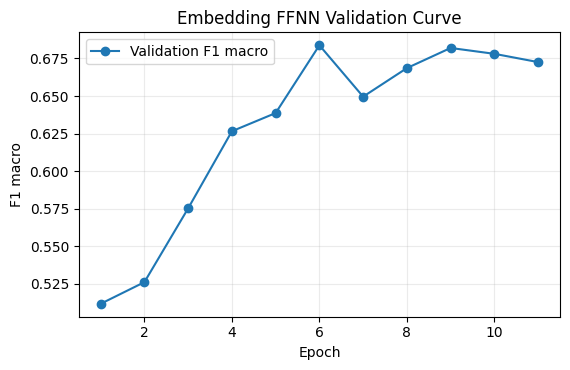

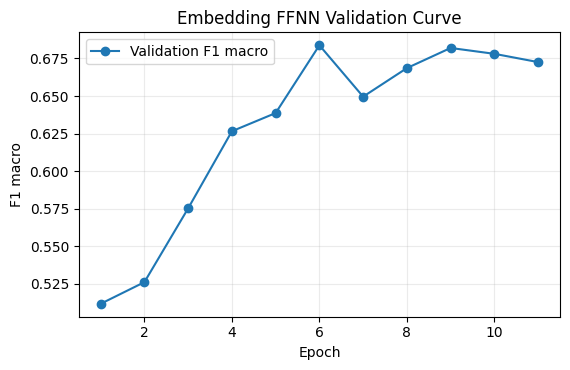

In [34]:
emb_model, emb_config, emb_best_params, emb_best_score, emb_trials, emb_history = train_or_load_ffnn(
    "embedding", X_train_ids, y_train, fixed_length, len(api_to_id), n_trials=15, max_epochs=20
)
print("Embedding FFNN best params:", emb_best_params)
print(f"Embedding FFNN best validation F1 macro: {emb_best_score:.4f}")
display(emb_trials.head(10).round(4))
display(emb_history.tail().round(4))
fig = save_training_curve_plot(emb_history, "Embedding FFNN", "embedding_training_curve")
display(fig)

Embedding FFNN test metrics


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1,roc_auc
0,0.9356,0.5789,0.5713,0.5789,0.5749,0.1832,0.9665,0.7696


Embedding FFNN confusion matrix


,pred_goodware_0,pred_malware_1
true_goodware_0,47,196
true_malware_1,223,6039


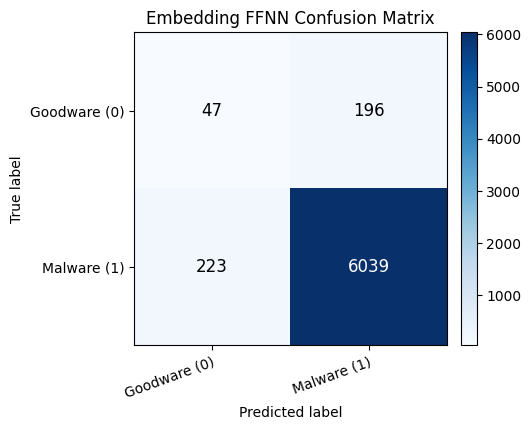

Embedding FFNN classification report


,precision,recall,f1-score,support
goodware_0,0.1741,0.1934,0.1832,243.0000
malware_1,0.9686,0.9644,0.9665,6262.0000
accuracy,0.9356,0.9356,0.9356,0.9356
macro avg,0.5713,0.5789,0.5749,6505.0000
weighted avg,0.9389,0.9356,0.9372,6505.0000


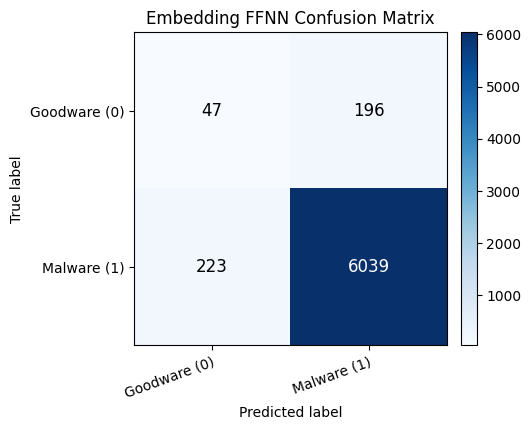

In [35]:
emb_test_loader = make_loader(X_test_ids, y_test, emb_best_params["batch_size"], "embedding")
emb_metrics, emb_cm, emb_report = evaluate_torch_classifier(emb_model, emb_test_loader)
save_task2_artifacts("embedding", emb_model, emb_config, emb_best_params, emb_best_score, emb_trials, emb_history, emb_metrics, emb_cm, emb_report)
print("Embedding FFNN test metrics")
display(emb_metrics)
print("Embedding FFNN confusion matrix")
display(emb_cm)
fig = save_task2_confusion_matrix_plot(emb_cm, "Embedding FFNN", "embedding_confusion_matrix")
display(fig)
print("Embedding FFNN classification report")
display(emb_report)

In [36]:
task2_comparison = pd.concat([
    ids_metrics.assign(model="Sequential-ID FFNN", best_val_f1_macro=ids_best_score),
    emb_metrics.assign(model="Embedding FFNN", best_val_f1_macro=emb_best_score),
], ignore_index=True)
cols = ["model", "best_val_f1_macro", "accuracy", "balanced_accuracy", "f1_macro", "f1_goodware_0", "f1_malware_1", "roc_auc"]
display(task2_comparison[cols].round(4))

task2_answers = [
    ["Sequence lengths", "No, the sequences do not all have the same length. Train ranges from 60 to 90 calls, while test ranges from 70 to 100 calls; the test distribution is shifted toward longer sequences."],
    ["Can FFNN handle variable length?", "No. A standard FFNN expects a fixed-size input vector, so every sample must have the same number of features."],
    ["Fixed-size estimate", f"I estimated the fixed length using only the train partition, choosing the maximum train length: {fixed_length}."],
    ["Padding/truncation", "Shorter sequences are padded with <PAD>=0. Longer sequences are truncated to the fixed length."],
    ["Longer test sequences", f"Test sequences longer than {fixed_length} are truncated; the preprocessing table reports how many sequences/API calls are affected."],
    ["Categorical mapping", "The sequential-ID model uses arbitrary numeric IDs as normalized scalar inputs; the embedding model learns a dense representation for each API call."],
]
display(pd.DataFrame(task2_answers, columns=["Question", "Answer"])
)

,model,best_val_f1_macro,accuracy,balanced_accuracy,f1_macro,f1_goodware_0,f1_malware_1,roc_auc
0,Sequential-ID FFNN,0.5403,0.9397,0.5138,0.5155,0.0622,0.9689,0.5618
1,Embedding FFNN,0.6838,0.9356,0.5789,0.5749,0.1832,0.9665,0.7696


,Question,Answer
0,Sequence lengths,"No, the sequences do not all have the same len..."
1,Can FFNN handle variable length?,No. A standard FFNN expects a fixed-size input...
2,Fixed-size estimate,I estimated the fixed length using only the tr...
3,Padding/truncation,Shorter sequences are padded with <PAD>=0. Lon...
4,Longer test sequences,Test sequences longer than 90 are truncated; t...
5,Categorical mapping,The sequential-ID model uses arbitrary numeric...


# Task 3: Recurrent Neural Network

RNN su sequenze di API call con padding dinamico per batch: Simple RNN, BiRNN e LSTM.

## Funzioni Task 3

**Checkpoint/cache.** Su Colab gli artefatti del Task 3 vengono salvati in `Google Drive/MyDrive/lab2/artifacts/task-3`. Con `FORCE_RETRAIN = False`, i modelli gia salvati vengono ricaricati e il training viene saltato.

In [37]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
    from torch.utils.data import DataLoader, Dataset
except ImportError as exc:
    raise ImportError("PyTorch is required for Task 3. On Colab, set Runtime > Change runtime type > GPU and rerun.") from exc

TASK3_FIGURE_DIR = Path("figures/task-3")
TASK3_ARTIFACT_DIR = get_task_artifact_dir("task-3")
print(f"Task 3 artifacts directory: {TASK3_ARTIFACT_DIR}")


class ApiSequenceDataset(Dataset):
    def __init__(self, sequences, labels, api_to_id):
        self.labels = np.array(labels, dtype=np.int64)
        unk_id = api_to_id["<UNK>"]
        self.encoded = [torch.tensor([api_to_id.get(api, unk_id) for api in seq], dtype=torch.long) for seq in sequences]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.encoded[idx], int(self.labels[idx])


def rnn_collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, lengths, labels


def make_rnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=256, val_size=0.15):
    idx_train, idx_val = train_test_split(
        np.arange(len(y_train)), test_size=val_size, stratify=y_train, random_state=RANDOM_STATE
    )
    X_tr = [X_train[i] for i in idx_train]
    X_val = [X_train[i] for i in idx_val]
    y_tr, y_val = y_train[idx_train], y_train[idx_val]

    train_ds = ApiSequenceDataset(X_tr, y_tr, api_to_id)
    val_ds = ApiSequenceDataset(X_val, y_val, api_to_id)
    test_ds = ApiSequenceDataset(X_test, y_test, api_to_id)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=rnn_collate_fn)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=rnn_collate_fn)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=rnn_collate_fn)
    return train_loader, val_loader, test_loader, y_tr


class SequenceRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=128, rnn_type="rnn", bidirectional=False, num_layers=1, dropout=0.2):
        super().__init__()
        self.rnn_type = rnn_type
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        rnn_dropout = dropout if num_layers > 1 else 0.0
        if rnn_type == "rnn":
            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        elif rnn_type == "lstm":
            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=bidirectional,
                dropout=rnn_dropout,
            )
        else:
            raise ValueError(f"Unknown rnn_type: {rnn_type}")
        output_dim = hidden_dim * (2 if bidirectional else 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(output_dim, output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim // 2, 2),
        )

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        if self.rnn_type == "lstm":
            _, (hidden, _) = self.rnn(packed)
        else:
            _, hidden = self.rnn(packed)
        if self.bidirectional:
            final_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            final_hidden = hidden[-1]
        return self.classifier(final_hidden)


def build_rnn_model(config):
    return SequenceRNNClassifier(
        vocab_size=config["vocab_size"],
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        rnn_type=config["rnn_type"],
        bidirectional=config["bidirectional"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    )


def evaluate_sequence_loss(model, data_loader, criterion, device=None):
    device = device or get_device()
    model = model.to(device)
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for xb, lengths, yb in data_loader:
            xb, lengths, yb = xb.to(device), lengths.to(device), yb.to(device)
            logits = model(xb, lengths)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)
            total_samples += yb.size(0)
    return total_loss / max(total_samples, 1)


def evaluate_sequence_classifier(model, data_loader, device=None):
    device = device or get_device()
    model = model.to(device)
    model.eval()
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for xb, lengths, yb in data_loader:
            xb, lengths = xb.to(device), lengths.to(device)
            logits = model(xb, lengths)
            probs = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)
            y_score.extend(probs)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)
    metrics = pd.DataFrame([{
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_goodware_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_malware_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }]).round(4)
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=[0, 1]),
        index=["true_goodware_0", "true_malware_1"],
        columns=["pred_goodware_0", "pred_malware_1"],
    )
    report = pd.DataFrame(classification_report(y_true, y_pred, labels=[0, 1], target_names=["goodware_0", "malware_1"], output_dict=True, zero_division=0)).T.round(4)
    return metrics, cm, report


def run_rnn_training_loop(model, train_loader, val_loader, y_train_split, lr, weight_decay, max_epochs=25, patience=5, device=None):
    device = device or get_device()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_train_split).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for xb, lengths, yb in train_loader:
            xb, lengths, yb = xb.to(device), lengths.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb, lengths), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _, _ = evaluate_sequence_classifier(model, val_loader, device=device)
        val_f1 = float(val_metrics.loc[0, "f1_macro"])
        val_loss = evaluate_sequence_loss(model, val_loader, criterion, device=device)
        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(val_loss),
            "val_f1_macro": val_f1,
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val_f1


def rnn_artifact_paths(model_kind, artifact_dir=TASK3_ARTIFACT_DIR):
    root = Path(artifact_dir) / model_kind
    return {
        "root": root,
        "checkpoint": root / "best_model.pt",
        "trials": root / "optuna_trials.csv",
        "history": root / "history.csv",
        "summary": root / "summary.json",
        "results": root / "results.json",
    }


def save_rnn_artifacts(model_kind, model, config, best_params, best_score, trials, history, metrics=None, cm=None, report=None):
    paths = rnn_artifact_paths(model_kind)
    paths["root"].mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": model.state_dict(), "config": config}, paths["checkpoint"])
    trials.to_csv(paths["trials"], index=False)
    history.to_csv(paths["history"], index=False)
    summary = {"model_kind": model_kind, "config": config, "best_params": best_params, "best_cv_score": float(best_score)}
    with paths["summary"].open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    if metrics is not None:
        results = {"metrics": metrics.to_dict(orient="records"), "confusion_matrix": cm.to_dict(), "classification_report": report.to_dict()}
        with paths["results"].open("w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)


def load_rnn_artifacts(model_kind, device=None):
    device = device or get_device()
    paths = rnn_artifact_paths(model_kind)
    required = [paths["checkpoint"], paths["trials"], paths["history"], paths["summary"]]
    if not all(path.exists() for path in required):
        return None
    checkpoint = safe_torch_load(paths["checkpoint"], device)
    with paths["summary"].open(encoding="utf-8") as f:
        summary = json.load(f)
    model = build_rnn_model(checkpoint["config"])
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    trials = pd.read_csv(paths["trials"])
    history = pd.read_csv(paths["history"])
    return model, summary["config"], summary["best_params"], summary["best_cv_score"], trials, history


def base_rnn_config(model_kind, vocab_size):
    if model_kind == "simple_rnn":
        return {"rnn_type": "rnn", "bidirectional": False, "vocab_size": vocab_size}
    if model_kind == "bidirectional_rnn":
        return {"rnn_type": "rnn", "bidirectional": True, "vocab_size": vocab_size}
    if model_kind == "lstm":
        return {"rnn_type": "lstm", "bidirectional": True, "vocab_size": vocab_size}
    raise ValueError(f"Unknown model_kind: {model_kind}")


def train_rnn_final_model(model_kind, X_train, y_train, api_to_id, vocab_size, best_params, final_epochs=60):
    set_torch_seed()
    device = get_device()
    config = base_rnn_config(model_kind, vocab_size)
    config.update({k: best_params[k] for k in ["embedding_dim", "hidden_dim", "num_layers", "dropout"]})
    train_loader, val_loader, _, y_tr = make_rnn_loaders(
        X_train, y_train, X_test, y_test, api_to_id, batch_size=best_params["batch_size"]
    )
    final_model = build_rnn_model(config)
    final_model, history, best_val_f1 = run_rnn_training_loop(
        final_model,
        train_loader,
        val_loader,
        y_tr,
        best_params["lr"],
        best_params["weight_decay"],
        max_epochs=final_epochs,
        patience=None,
        device=device,
    )
    return final_model, config, history, best_val_f1


def train_rnn_with_optuna(model_kind, X_train, y_train, api_to_id, vocab_size, n_trials=10, optuna_epochs=20, final_epochs=60):
    set_torch_seed()
    device = get_device()

    def objective(trial):
        params = {
            "embedding_dim": trial.suggest_categorical("embedding_dim", [16, 32, 64]),
            "hidden_dim": trial.suggest_categorical("hidden_dim", [64, 128, 256]),
            "num_layers": trial.suggest_categorical("num_layers", [1, 2]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "lr": trial.suggest_float("lr", 1e-5, 1e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [128, 256]),
        }
        config = base_rnn_config(model_kind, vocab_size)
        config.update({k: params[k] for k in ["embedding_dim", "hidden_dim", "num_layers", "dropout"]})
        train_loader, val_loader, _, y_tr = make_rnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=params["batch_size"])
        model = build_rnn_model(config)
        _, _, best_val_f1 = run_rnn_training_loop(
            model, train_loader, val_loader, y_tr, params["lr"], params["weight_decay"], max_epochs=optuna_epochs, patience=4, device=device
        )
        return best_val_f1

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params

    final_model, config, history, best_val_f1 = train_rnn_final_model(
        model_kind, X_train, y_train, api_to_id, vocab_size, best_params, final_epochs=final_epochs
    )
    trials = study.trials_dataframe(attrs=("number", "value", "params", "state")).sort_values("value", ascending=False).reset_index(drop=True)
    return final_model, config, best_params, best_val_f1, trials, history


def train_or_load_rnn(model_kind, X_train, y_train, api_to_id, vocab_size, force_retrain=FORCE_RETRAIN, n_trials=10, optuna_epochs=20, final_epochs=60):
    if not force_retrain:
        cached = load_rnn_artifacts(model_kind)
        if cached is not None:
            model, config, best_params, best_score, trials, history = cached
            if "val_loss" in history.columns:
                print(f"Loaded {model_kind} artifacts from cache.")
                return cached
            print(f"Loaded {model_kind} Optuna results from cache; retraining final model to log validation loss.")
            model, config, history, best_score = train_rnn_final_model(
                model_kind, X_train, y_train, api_to_id, vocab_size, best_params, final_epochs=final_epochs
            )
            save_rnn_artifacts(model_kind, model, config, best_params, best_score, trials, history)
            return model, config, best_params, best_score, trials, history
    print(f"Training {model_kind} with Optuna on {get_device()}.")
    model, config, best_params, best_score, trials, history = train_rnn_with_optuna(
        model_kind, X_train, y_train, api_to_id, vocab_size, n_trials=n_trials, optuna_epochs=optuna_epochs, final_epochs=final_epochs
    )
    save_rnn_artifacts(model_kind, model, config, best_params, best_score, trials, history)
    return model, config, best_params, best_score, trials, history


def save_task3_confusion_matrix_plot(cm, model_label, filename, figure_dir=TASK3_FIGURE_DIR):
    return save_confusion_matrix_plot(cm, figure_dir=figure_dir, filename=filename, title=f"{model_label} Confusion Matrix")


def save_task3_training_curve_plot(history, model_label, filename, figure_dir=TASK3_FIGURE_DIR):
    return save_training_curve_plot(history, model_label, filename, figure_dir=figure_dir)


def save_task3_loss_curves_plot(rnn_results, figure_dir=TASK3_FIGURE_DIR, filename="loss_curves"):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    ordered_models = [
        ("simple_rnn", "Simple RNN"),
        ("bidirectional_rnn", "BiRNN"),
        ("lstm", "BiLSTM"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=False)

    for ax, (model_key, model_label) in zip(axes, ordered_models):
        history = rnn_results[model_key]["history"]
        if "val_loss" not in history.columns:
            raise ValueError("History does not contain val_loss. Rerun the final training cell to regenerate Task 3 artifacts.")
        ax.plot(history["epoch"], history["train_loss"], marker="o", linewidth=1.8, label="Train loss")
        ax.plot(history["epoch"], history["val_loss"], marker="o", linewidth=1.8, label="Validation loss")
        ax.set_title(model_label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.grid(alpha=0.25)
        ax.legend()

    fig.suptitle("RNN Train vs Validation Loss", y=1.04)
    fig.tight_layout()
    fig.savefig(figure_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    return fig


def rnn_padding_memory_report(X_train, X_test, fixed_length):
    rows = []
    for split, X in [("train", X_train), ("test", X_test)]:
        lengths = np.array([len(seq) for seq in X])
        rows.append({
            "split": split,
            "samples": len(X),
            "ffnn_tokens_fixed_padding": int(len(X) * fixed_length),
            "rnn_tokens_without_batch_padding": int(lengths.sum()),
            "ratio_actual_to_ffnn_fixed": float(lengths.sum() / (len(X) * fixed_length)),
            "max_sequence_length": int(lengths.max()),
        })
    return pd.DataFrame(rows).round(4)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Task 3 artifacts directory: /content/drive/MyDrive/lab2/artifacts/task-3


## Output per rispondere al Task 3

In [38]:
rnn_memory_summary = rnn_padding_memory_report(X_train, X_test, fixed_length)
display(rnn_memory_summary)

rnn_answers_pre = [
    ["Padding", "Yes. RNNs still need padding for batching, but padding can be dynamic: each mini-batch is padded only to the longest sequence in that batch."],
    ["Test truncation", "No truncation is required for RNNs. They can process sequences longer than the maximum training length, as long as the API calls are mapped to known IDs or <UNK>."],
    ["Memory efficiency", "RNN padding can be more memory efficient than FFNN fixed padding because batches do not need to be padded to one global fixed length."],
    ["Speed", "RNNs are usually slower than FFNNs because recurrent computation is sequential across timesteps and harder to parallelize."],
]
display(pd.DataFrame(rnn_answers_pre, columns=["Question", "Answer"]))

,split,samples,ffnn_tokens_fixed_padding,rnn_tokens_without_batch_padding,ratio_actual_to_ffnn_fixed,max_sequence_length
0,train,16325,1469250,1224878,0.8337,90
1,test,6505,585450,561584,0.9592,100


,Question,Answer
0,Padding,"Yes. RNNs still need padding for batching, but..."
1,Test truncation,No truncation is required for RNNs. They can p...
2,Memory efficiency,RNN padding can be more memory efficient than ...
3,Speed,RNNs are usually slower than FFNNs because rec...


Loaded simple_rnn artifacts from cache.
Simple one-directional RNN
Best params: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.4077307142274171, 'lr': 0.0002592475660475158, 'weight_decay': 0.0008241925264876454, 'batch_size': 128}
Best validation F1 macro: 0.8282


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,5,0.7102,128,0.4077,64,128,0.0003,1,0.0008,COMPLETE
1,3,0.6417,128,0.2600,64,128,0.0001,1,0.0000,COMPLETE
2,8,0.5723,128,0.4648,16,64,0.0004,1,0.0003,COMPLETE
3,0,0.5722,128,0.3006,32,64,0.0003,2,0.0000,COMPLETE
4,6,0.5604,128,0.3648,64,64,0.0002,2,0.0035,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
55,56,0.1382,0.6030,0.7787
56,57,0.1290,0.4415,0.8003
57,58,0.1152,0.5363,0.7986
58,59,0.1560,0.4781,0.8001
59,60,0.1337,0.7144,0.8040


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9699,0.8083,0.7879,0.8083,0.7977,0.6111,0.9843


,pred_goodware_0,pred_malware_1
true_goodware_0,154,89
true_malware_1,107,6155


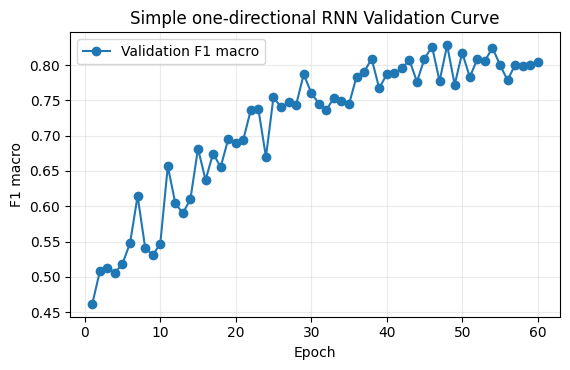

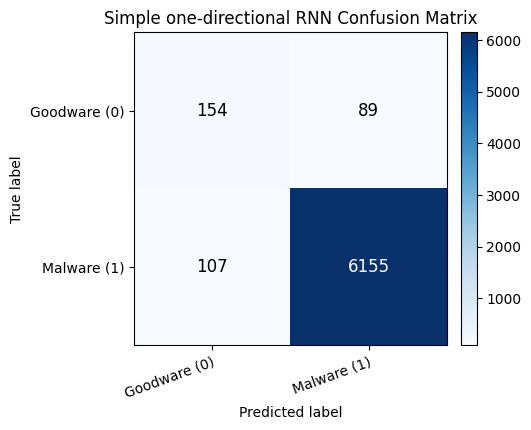

,precision,recall,f1-score,support
goodware_0,0.5900,0.6337,0.6111,243.0000
malware_1,0.9857,0.9829,0.9843,6262.0000
accuracy,0.9699,0.9699,0.9699,0.9699
macro avg,0.7879,0.8083,0.7977,6505.0000
weighted avg,0.9710,0.9699,0.9704,6505.0000


Loaded bidirectional_rnn artifacts from cache.
Bidirectional RNN
Best params: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.4828160165372797, 'lr': 0.0004138040112561013, 'weight_decay': 1.6536937182824424e-05, 'batch_size': 256}
Best validation F1 macro: 0.8175


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,2,0.6828,256,0.4828,64,128,0.0004,2,0.0000,COMPLETE
1,3,0.6691,128,0.2600,64,128,0.0001,1,0.0000,COMPLETE
2,9,0.6486,256,0.2136,32,128,0.0004,2,0.0028,COMPLETE
3,0,0.6219,128,0.3006,32,64,0.0003,2,0.0000,COMPLETE
4,6,0.6114,128,0.3648,64,64,0.0002,2,0.0035,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
55,56,0.0865,1.3019,0.8011
56,57,0.1222,0.9664,0.7681
57,58,0.0945,1.4987,0.7646
58,59,0.0882,1.1792,0.7578
59,60,0.0756,1.0270,0.8175


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9637,0.821,0.749,0.821,0.7798,0.5786,0.981


,pred_goodware_0,pred_malware_1
true_goodware_0,162,81
true_malware_1,155,6107


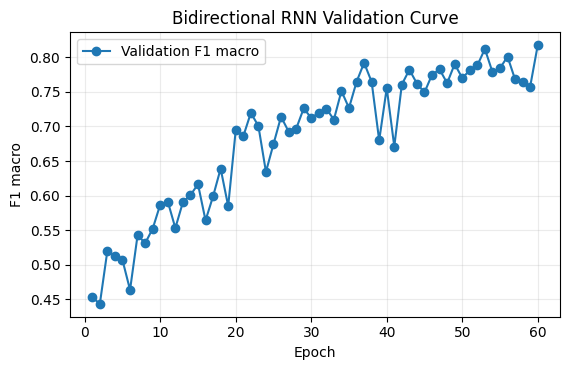

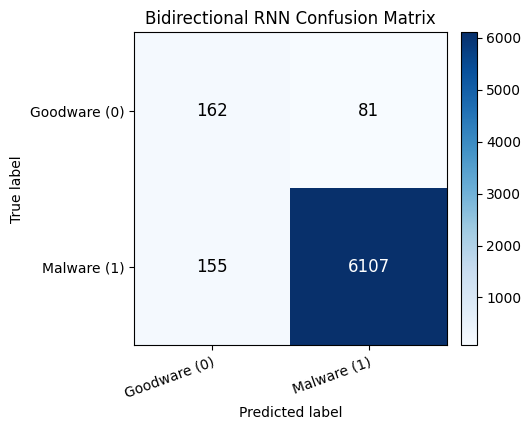

,precision,recall,f1-score,support
goodware_0,0.5110,0.6667,0.5786,243.0000
malware_1,0.9869,0.9752,0.9810,6262.0000
accuracy,0.9637,0.9637,0.9637,0.9637
macro avg,0.7490,0.8210,0.7798,6505.0000
weighted avg,0.9691,0.9637,0.9660,6505.0000


Loaded lstm artifacts from cache.
Bidirectional LSTM
Best params: {'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.4828160165372797, 'lr': 0.0004138040112561013, 'weight_decay': 1.6536937182824424e-05, 'batch_size': 256}
Best validation F1 macro: 0.8594


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,2,0.7595,256,0.4828,64,128,0.0004,2,0.0000,COMPLETE
1,0,0.7559,128,0.3006,32,64,0.0003,2,0.0000,COMPLETE
2,5,0.7449,128,0.4077,64,128,0.0003,1,0.0008,COMPLETE
3,9,0.6872,256,0.2136,32,128,0.0004,2,0.0028,COMPLETE
4,3,0.6616,128,0.2600,64,128,0.0001,1,0.0000,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
55,56,0.0351,1.7185,0.8594
56,57,0.0336,1.1368,0.8358
57,58,0.0364,1.6140,0.8350
58,59,0.0550,1.3455,0.8310
59,60,0.0440,1.3049,0.8396


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9748,0.8663,0.8144,0.8663,0.8381,0.6894,0.9869


,pred_goodware_0,pred_malware_1
true_goodware_0,182,61
true_malware_1,103,6159


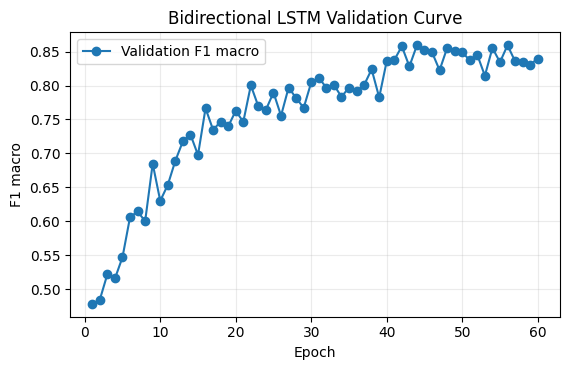

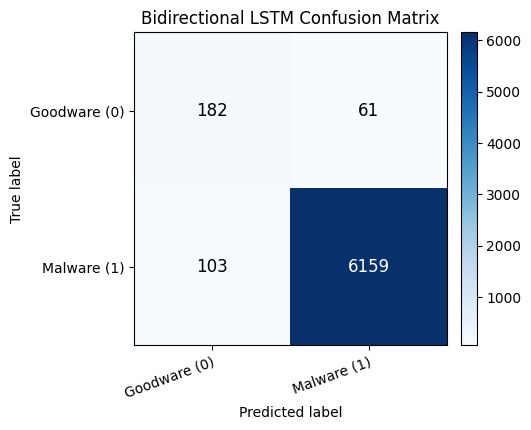

,precision,recall,f1-score,support
goodware_0,0.6386,0.7490,0.6894,243.0000
malware_1,0.9902,0.9836,0.9869,6262.0000
accuracy,0.9748,0.9748,0.9748,0.9748
macro avg,0.8144,0.8663,0.8381,6505.0000
weighted avg,0.9771,0.9748,0.9757,6505.0000


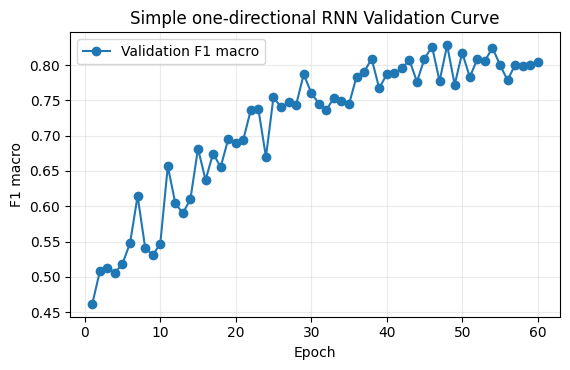

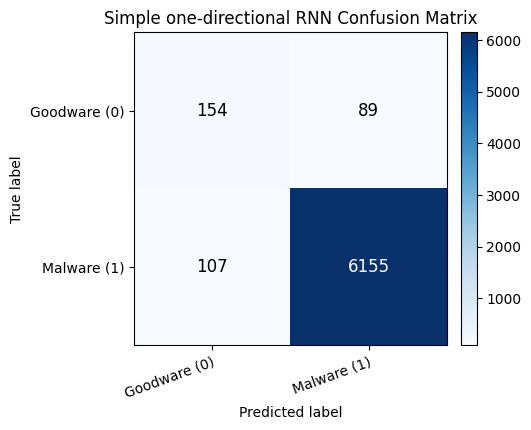

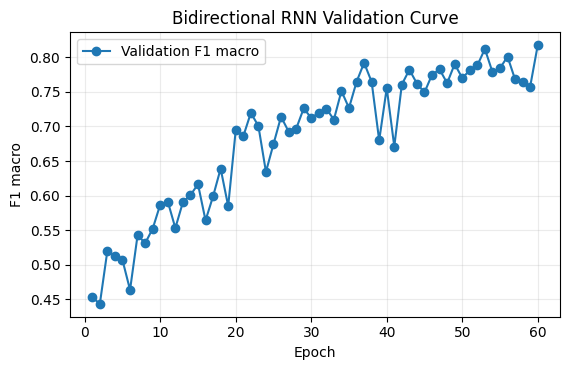

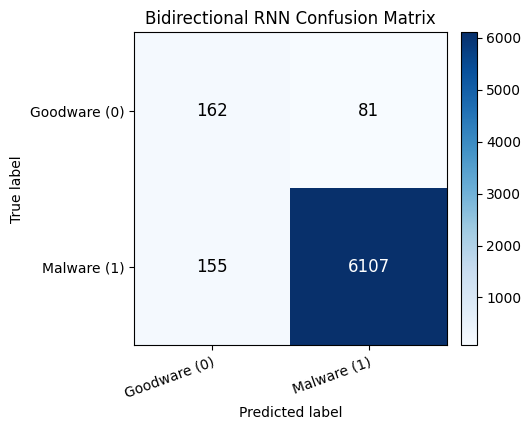

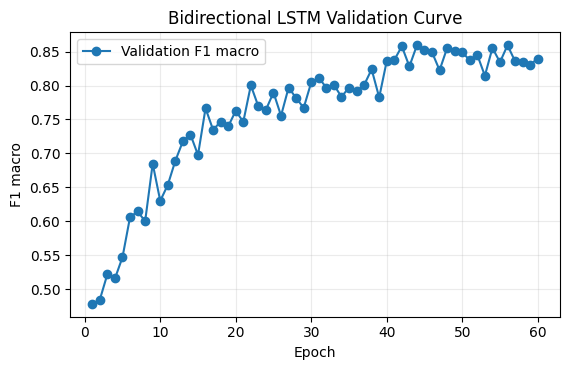

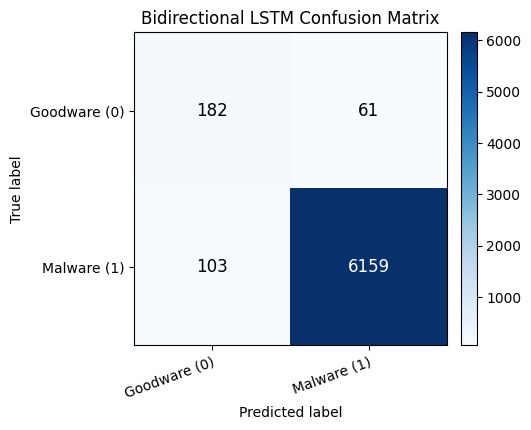

In [39]:
rnn_model_specs = {
    "simple_rnn": "Simple one-directional RNN",
    "bidirectional_rnn": "Bidirectional RNN",
    "lstm": "Bidirectional LSTM",
}
rnn_results = {}

for model_kind, model_label in rnn_model_specs.items():
    trained_model, config, best_params, best_score, trials, history = train_or_load_rnn(
        model_kind, X_train, y_train, api_to_id, len(api_to_id), n_trials=10, optuna_epochs=20, final_epochs=60
    )
    batch_size = best_params["batch_size"]
    _, _, test_loader, _ = make_rnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=batch_size)
    metrics, cm, report = evaluate_sequence_classifier(trained_model, test_loader)
    save_rnn_artifacts(model_kind, trained_model, config, best_params, best_score, trials, history, metrics, cm, report)
    fig_curve = save_task3_training_curve_plot(history, model_label, f"{model_kind}_training_curve")
    fig_cm = save_task3_confusion_matrix_plot(cm, model_label, f"{model_kind}_confusion_matrix")
    rnn_results[model_kind] = {
        "label": model_label,
        "model": trained_model,
        "config": config,
        "best_params": best_params,
        "best_score": best_score,
        "trials": trials,
        "history": history,
        "metrics": metrics,
        "cm": cm,
        "report": report,
        "fig_curve": fig_curve,
        "fig_cm": fig_cm,
    }
    print(model_label)
    print("Best params:", best_params)
    print(f"Best validation F1 macro: {best_score:.4f}")
    display(trials.head(5).round(4))
    display(history.tail().round(4))
    display(metrics)
    display(cm)
    display(fig_curve)
    display(fig_cm)
    display(report)

,model,best_val_f1_macro,accuracy,balanced_accuracy,f1_macro,f1_goodware_0,f1_malware_1
0,Simple one-directional RNN,0.8282,0.9699,0.8083,0.7977,0.6111,0.9843
1,Bidirectional RNN,0.8175,0.9637,0.8210,0.7798,0.5786,0.9810
2,Bidirectional LSTM,0.8594,0.9748,0.8663,0.8381,0.6894,0.9869


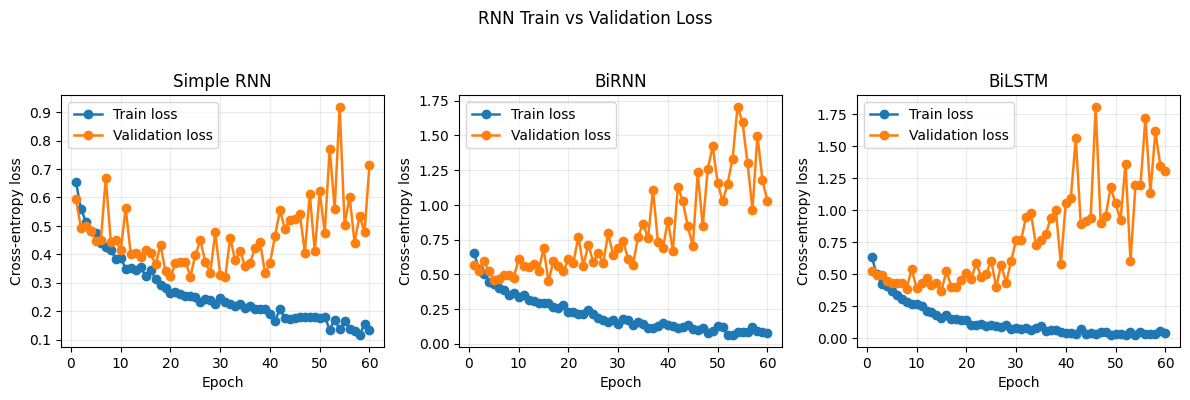

,Question,Answer
0,Training stability,RNN stability and overfitting should be assess...
1,Baseline comparison,The final comparison table should be read agai...


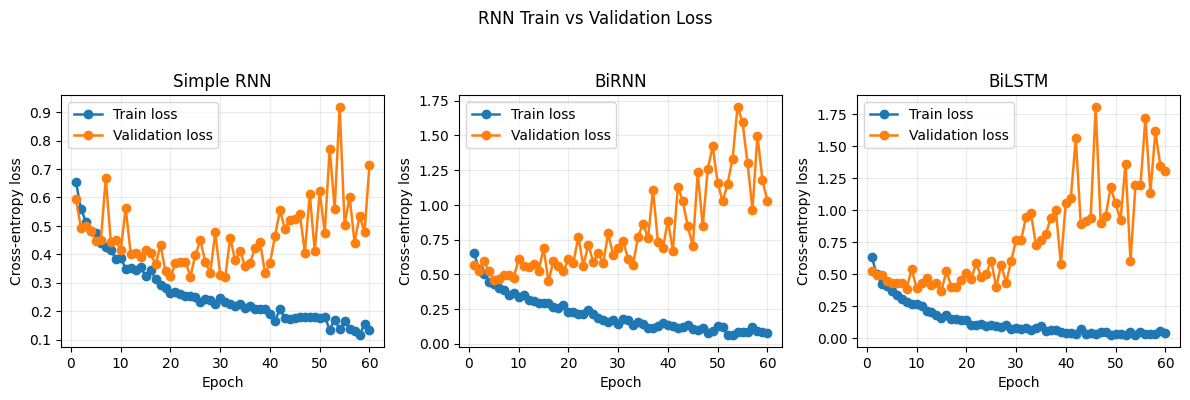

In [40]:
rnn_comparison = pd.concat([
    result["metrics"].assign(model=result["label"], best_val_f1_macro=result["best_score"])
    for result in rnn_results.values()
], ignore_index=True)
cols = ["model", "best_val_f1_macro", "accuracy", "balanced_accuracy", "f1_macro", "f1_goodware_0", "f1_malware_1"]
display(rnn_comparison[cols].round(4))

fig = save_task3_loss_curves_plot(rnn_results)
display(fig)

task3_answers = [
    ["Training stability", "RNN stability and overfitting should be assessed from the train/validation loss curves; validation macro F1 remains useful because it matches the model-selection objective on the imbalanced data."],
    ["Baseline comparison", "The final comparison table should be read against the frequency-based Logistic Regression baseline from Task 1. The RNNs model order, but the baseline may still be stronger because API frequencies are highly informative for this dataset."],
]
display(pd.DataFrame(task3_answers, columns=["Question", "Answer"]))

# Task 4: Graph Neural Network

GNN su grafi di transizione delle API call: Simple GCN, GraphSAGE e GAT.


## Funzioni Task 4

**Checkpoint/cache.** Su Colab gli artefatti del Task 4 vengono salvati in `Google Drive/MyDrive/lab2/artifacts/task-4`. Con `FORCE_RETRAIN = False`, i modelli gia salvati vengono ricaricati e il training viene saltato.


In [41]:
try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader as GeometricDataLoader
    from torch_geometric.nn import GATConv, GCNConv, SAGEConv, global_add_pool, global_max_pool, global_mean_pool
except ImportError:
    if is_colab():
        import sys
        import subprocess
        print("Installing torch-geometric for Colab runtime...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"])
        from torch_geometric.data import Data
        from torch_geometric.loader import DataLoader as GeometricDataLoader
        from torch_geometric.nn import GATConv, GCNConv, SAGEConv, global_add_pool, global_max_pool, global_mean_pool
    else:
        raise ImportError("torch-geometric is required for Task 4. Run this section on Colab or install torch-geometric locally.")

TASK4_FIGURE_DIR = Path("figures/task-4")
TASK4_ARTIFACT_DIR = get_task_artifact_dir("task-4")
print(f"Task 4 artifacts directory: {TASK4_ARTIFACT_DIR}")


def sequence_to_transition_graph(sequence, api_to_id):
    unk_id = api_to_id["<UNK>"]
    node_api_ids = []
    local_index = {}
    for api in sequence:
        api_id = api_to_id.get(api, unk_id)
        if api_id not in local_index:
            local_index[api_id] = len(node_api_ids)
            node_api_ids.append(api_id)

    edges = set()
    for src_api, dst_api in zip(sequence[:-1], sequence[1:]):
        src_id = api_to_id.get(src_api, unk_id)
        dst_id = api_to_id.get(dst_api, unk_id)
        edges.add((local_index[src_id], local_index[dst_id]))

    if edges:
        edge_index = torch.tensor(sorted(edges), dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    x = torch.tensor(node_api_ids, dtype=torch.long).view(-1, 1)
    return x, edge_index


def build_graph_dataset(sequences, labels, api_to_id):
    graphs = []
    for seq, label in zip(sequences, labels):
        x, edge_index = sequence_to_transition_graph(seq, api_to_id)
        graphs.append(Data(x=x, edge_index=edge_index, y=torch.tensor([int(label)], dtype=torch.long)))
    return graphs


def graph_dataset_report(X_train, X_test, api_to_id):
    rows = []
    for split, X in [("train", X_train), ("test", X_test)]:
        n_nodes, n_edges, n_loops = [], [], []
        for seq in X:
            x, edge_index = sequence_to_transition_graph(seq, api_to_id)
            n_nodes.append(int(x.size(0)))
            n_edges.append(int(edge_index.size(1)))
            if edge_index.numel() == 0:
                n_loops.append(0)
            else:
                n_loops.append(int((edge_index[0] == edge_index[1]).sum().item()))
        rows.append({
            "split": split,
            "samples": len(X),
            "avg_nodes": float(np.mean(n_nodes)),
            "avg_edges": float(np.mean(n_edges)),
            "avg_self_loops": float(np.mean(n_loops)),
            "max_nodes": int(np.max(n_nodes)),
            "max_edges": int(np.max(n_edges)),
        })
    return pd.DataFrame(rows).round(3)


def make_gnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=128, val_size=0.15):
    idx_train, idx_val = train_test_split(
        np.arange(len(y_train)), test_size=val_size, stratify=y_train, random_state=RANDOM_STATE
    )
    X_tr = [X_train[i] for i in idx_train]
    X_val = [X_train[i] for i in idx_val]
    y_tr, y_val = y_train[idx_train], y_train[idx_val]

    train_graphs = build_graph_dataset(X_tr, y_tr, api_to_id)
    val_graphs = build_graph_dataset(X_val, y_val, api_to_id)
    test_graphs = build_graph_dataset(X_test, y_test, api_to_id)

    train_loader = GeometricDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GeometricDataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = GeometricDataLoader(test_graphs, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader, y_tr


class GraphTransitionClassifier(nn.Module):
    def __init__(self, vocab_size, model_kind="gcn", embedding_dim=32, hidden_dim=128, num_layers=2, dropout=0.2, aggregation="mean", heads=2):
        super().__init__()
        self.model_kind = model_kind
        self.dropout = dropout
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList()
        self.output_dims = []

        in_dim = embedding_dim
        for layer_idx in range(num_layers):
            if model_kind == "gcn":
                conv = GCNConv(in_dim, hidden_dim)
                out_dim = hidden_dim
            elif model_kind == "sage":
                conv = SAGEConv(in_dim, hidden_dim, aggr=aggregation)
                out_dim = hidden_dim
            elif model_kind == "gat":
                conv_heads = heads if layer_idx < num_layers - 1 else 1
                conv = GATConv(in_dim, hidden_dim, heads=conv_heads, concat=True, dropout=dropout)
                out_dim = hidden_dim * conv_heads
            else:
                raise ValueError(f"Unknown model_kind: {model_kind}")
            self.convs.append(conv)
            self.output_dims.append(out_dim)
            in_dim = out_dim

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, max(in_dim // 2, 8)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(in_dim // 2, 8), 2),
        )

    def forward(self, data):
        x = self.embedding(data.x.view(-1))
        edge_index = data.edge_index
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        if self.model_kind == "gcn":
            pooled = global_add_pool(x, data.batch)
        elif self.model_kind == "sage":
            pooled = global_mean_pool(x, data.batch)
        else:
            pooled = global_max_pool(x, data.batch)
        return self.classifier(pooled)


def build_gnn_model(config):
    return GraphTransitionClassifier(
        vocab_size=config["vocab_size"],
        model_kind=config["model_kind"],
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        aggregation=config.get("aggregation", "mean"),
        heads=config.get("heads", 2),
    )


def evaluate_gnn_classifier(model, data_loader, device=None):
    device = device or get_device()
    model = model.to(device)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            logits = model(batch)
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(batch.y.detach().cpu().numpy())
            y_pred.extend(preds)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    metrics = pd.DataFrame([{
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_goodware_0": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1_malware_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }]).round(4)
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=[0, 1]),
        index=["true_goodware_0", "true_malware_1"],
        columns=["pred_goodware_0", "pred_malware_1"],
    )
    report = pd.DataFrame(classification_report(y_true, y_pred, labels=[0, 1], target_names=["goodware_0", "malware_1"], output_dict=True, zero_division=0)).T.round(4)
    return metrics, cm, report


def evaluate_gnn_loss(model, data_loader, criterion, device=None):
    device = device or get_device()
    model = model.to(device)
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            loss = criterion(model(batch), batch.y)
            total_loss += loss.item() * batch.y.size(0)
            total_samples += batch.y.size(0)
    return total_loss / max(total_samples, 1)


def run_gnn_training_loop(model, train_loader, val_loader, y_train_split, lr, weight_decay, max_epochs=40, patience=8, device=None):
    device = device or get_device()
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_train_split).to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_val_f1 = -np.inf
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch.y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _, _ = evaluate_gnn_classifier(model, val_loader, device=device)
        val_f1 = float(val_metrics.loc[0, "f1_macro"])
        val_loss = evaluate_gnn_loss(model, val_loader, criterion, device=device)
        history.append({"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": float(val_loss), "val_f1_macro": val_f1})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if patience is not None and epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_val_f1


def gnn_artifact_paths(model_kind, artifact_dir=TASK4_ARTIFACT_DIR):
    root = Path(artifact_dir) / model_kind
    return {
        "root": root,
        "checkpoint": root / "best_model.pt",
        "trials": root / "optuna_trials.csv",
        "history": root / "history.csv",
        "summary": root / "summary.json",
        "results": root / "results.json",
    }


def save_gnn_artifacts(model_kind, model, config, best_params, best_score, trials, history, metrics=None, cm=None, report=None):
    paths = gnn_artifact_paths(model_kind)
    paths["root"].mkdir(parents=True, exist_ok=True)
    torch.save({"state_dict": model.state_dict(), "config": config}, paths["checkpoint"])
    trials.to_csv(paths["trials"], index=False)
    history.to_csv(paths["history"], index=False)
    summary = {"model_kind": model_kind, "config": config, "best_params": best_params, "best_cv_score": float(best_score)}
    with paths["summary"].open("w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)
    if metrics is not None:
        results = {"metrics": metrics.to_dict(orient="records"), "confusion_matrix": cm.to_dict(), "classification_report": report.to_dict()}
        with paths["results"].open("w", encoding="utf-8") as f:
            json.dump(results, f, indent=2)


def load_gnn_artifacts(model_kind, device=None):
    device = device or get_device()
    paths = gnn_artifact_paths(model_kind)
    required = [paths["checkpoint"], paths["trials"], paths["history"], paths["summary"]]
    if not all(path.exists() for path in required):
        return None
    checkpoint = safe_torch_load(paths["checkpoint"], device)
    with paths["summary"].open(encoding="utf-8") as f:
        summary = json.load(f)
    model = build_gnn_model(checkpoint["config"])
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device)
    trials = pd.read_csv(paths["trials"])
    history = pd.read_csv(paths["history"])
    return model, summary["config"], summary["best_params"], summary["best_cv_score"], trials, history


def base_gnn_config(model_kind, vocab_size):
    return {"model_kind": model_kind, "vocab_size": vocab_size}


def train_gnn_with_optuna(model_kind, X_train, y_train, api_to_id, vocab_size, n_trials=10, optuna_epochs=25, final_epochs=50):
    set_torch_seed()
    device = get_device()

    def objective(trial):
        params = {
            "embedding_dim": trial.suggest_categorical("embedding_dim", [16, 32, 64]),
            "hidden_dim": trial.suggest_categorical("hidden_dim", [64, 128, 256]),
            "num_layers": trial.suggest_categorical("num_layers", [2, 3]),
            "dropout": trial.suggest_float("dropout", 0.0, 0.5),
            "lr": trial.suggest_float("lr", 1e-5, 3e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        }
        if model_kind == "sage":
            params["aggregation"] = trial.suggest_categorical("aggregation", ["mean", "max"])
        else:
            params["aggregation"] = "mean"
        if model_kind == "gat":
            params["heads"] = trial.suggest_categorical("heads", [2, 4])
        else:
            params["heads"] = 1

        config = base_gnn_config(model_kind, vocab_size)
        config.update({k: params[k] for k in ["embedding_dim", "hidden_dim", "num_layers", "dropout", "aggregation", "heads"]})
        train_loader, val_loader, _, y_tr = make_gnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=params["batch_size"])
        model = build_gnn_model(config)
        _, _, best_val_f1 = run_gnn_training_loop(
            model, train_loader, val_loader, y_tr, params["lr"], params["weight_decay"], max_epochs=optuna_epochs, patience=5, device=device
        )
        return best_val_f1

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params
    best_params.setdefault("aggregation", "mean")
    best_params.setdefault("heads", 1)

    config = base_gnn_config(model_kind, vocab_size)
    config.update({k: best_params[k] for k in ["embedding_dim", "hidden_dim", "num_layers", "dropout", "aggregation", "heads"]})
    train_loader, val_loader, _, y_tr = make_gnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=best_params["batch_size"])
    final_model = build_gnn_model(config)
    final_model, history, best_val_f1 = run_gnn_training_loop(
        final_model, train_loader, val_loader, y_tr, best_params["lr"], best_params["weight_decay"], max_epochs=final_epochs, patience=8, device=device
    )
    trials = study.trials_dataframe(attrs=("number", "value", "params", "state")).sort_values("value", ascending=False).reset_index(drop=True)
    return final_model, config, best_params, best_val_f1, trials, history


def train_or_load_gnn(model_kind, X_train, y_train, api_to_id, vocab_size, force_retrain=FORCE_RETRAIN, n_trials=10, optuna_epochs=25, final_epochs=50):
    if not force_retrain:
        cached = load_gnn_artifacts(model_kind)
        if cached is not None:
            print(f"Loaded {model_kind} artifacts from cache.")
            return cached
    print(f"Training {model_kind} GNN with Optuna on {get_device()}.")
    model, config, best_params, best_score, trials, history = train_gnn_with_optuna(
        model_kind, X_train, y_train, api_to_id, vocab_size, n_trials=n_trials, optuna_epochs=optuna_epochs, final_epochs=final_epochs
    )
    save_gnn_artifacts(model_kind, model, config, best_params, best_score, trials, history)
    return model, config, best_params, best_score, trials, history


def save_task4_confusion_matrix_plot(cm, model_label, filename, figure_dir=TASK4_FIGURE_DIR):
    return save_confusion_matrix_plot(cm, figure_dir=figure_dir, filename=filename, title=f"{model_label} Confusion Matrix")


def save_task4_training_curve_plot(history, model_label, filename, figure_dir=TASK4_FIGURE_DIR):
    return save_training_curve_plot(history, model_label, filename, figure_dir=figure_dir)


def save_task4_loss_curves_plot(gnn_results, figure_dir=TASK4_FIGURE_DIR, filename="loss_curves"):
    import matplotlib.pyplot as plt

    figure_dir = Path(figure_dir)
    figure_dir.mkdir(parents=True, exist_ok=True)
    ordered_models = [("gcn", "GCN"), ("sage", "GraphSAGE"), ("gat", "GAT")]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=False)
    for ax, (model_key, model_label) in zip(axes, ordered_models):
        history = gnn_results[model_key]["history"]
        ax.plot(history["epoch"], history["train_loss"], marker="o", linewidth=1.8, label="Train loss")
        ax.plot(history["epoch"], history["val_loss"], marker="o", linewidth=1.8, label="Validation loss")
        ax.set_title(model_label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Cross-entropy loss")
        ax.grid(alpha=0.25)
        ax.legend()
    fig.suptitle("GNN Train vs Validation Loss", y=1.04)
    fig.tight_layout()
    fig.savefig(figure_dir / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    fig.savefig(figure_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
    return fig


Installing torch-geometric for Colab runtime...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Task 4 artifacts directory: /content/drive/MyDrive/lab2/artifacts/task-4


## Output per rispondere al Task 4


In [42]:
gnn_graph_summary = graph_dataset_report(X_train, X_test, api_to_id)
display(gnn_graph_summary)

gnn_answers_pre = [
    ["Padding", "No sequence padding is required for the GNN representation. Each sample is a graph with its own number of nodes and edges, and batching stores graphs as disconnected components."],
    ["Test truncation", "No truncation is required. Larger test graphs can be processed because GNN layers reuse the same message-passing functions independently of graph size."],
    ["Advantage/loss", "A GNN can model API transitions without sequential unrolling, which can be easier to batch than an RNN. However, converting the sequence to an unweighted transition graph loses exact temporal positions and repeated transition counts."],
]
display(pd.DataFrame(gnn_answers_pre, columns=["Question", "Answer"]))


,split,samples,avg_nodes,avg_edges,avg_self_loops,max_nodes,max_edges
0,train,16325,21.947,39.643,0.0,41,72
1,test,6505,24.279,45.104,0.0,45,76


,Question,Answer
0,Padding,No sequence padding is required for the GNN re...
1,Test truncation,No truncation is required. Larger test graphs ...
2,Advantage/loss,A GNN can model API transitions without sequen...


[I 2026-06-13 15:46:51,965] A new study created in memory with name: no-name-2b25c363-e36f-43ad-b480-75cfd2ac4fa5


Training gcn GNN with Optuna on cuda.


[I 2026-06-13 15:47:54,607] Trial 0 finished with value: 0.7338 and parameters: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.3005575058716044, 'lr': 0.0005675206026988746, 'weight_decay': 1.2087541473056965e-06, 'batch_size': 64}. Best is trial 0 with value: 0.7338.
[I 2026-06-13 15:48:08,942] Trial 1 finished with value: 0.5598 and parameters: {'embedding_dim': 64, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.14607232426760908, 'lr': 8.082071885709241e-05, 'weight_decay': 6.672367170464208e-05, 'batch_size': 64}. Best is trial 0 with value: 0.7338.
[I 2026-06-13 15:48:30,433] Trial 2 finished with value: 0.5281 and parameters: {'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.15230688458668534, 'lr': 1.7456037635797413e-05, 'weight_decay': 0.0005456725485601478, 'batch_size': 256}. Best is trial 0 with value: 0.7338.
[I 2026-06-13 15:48:57,446] Trial 3 finished with value: 0.5835 and parameters: {'embedding_dim': 32, 'hidden_dim': 64, '

Simple GCN
Best params: {'embedding_dim': 32, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.3005575058716044, 'lr': 0.0005675206026988746, 'weight_decay': 1.2087541473056965e-06, 'batch_size': 64, 'aggregation': 'mean', 'heads': 1}
Best validation F1 macro: 0.7384


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,0,0.7338,64,0.3006,32,64,0.0006,3,0.0000,COMPLETE
1,7,0.6411,128,0.2052,32,64,0.0007,2,0.0000,COMPLETE
2,4,0.6390,256,0.1405,32,128,0.0002,2,0.0000,COMPLETE
3,8,0.6255,256,0.4037,16,64,0.0017,2,0.0000,COMPLETE
4,3,0.5835,256,0.4848,32,64,0.0008,2,0.0057,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
30,31,0.2725,0.4087,0.7008
31,32,0.2479,0.4076,0.6901
32,33,0.2500,0.4207,0.6551
33,34,0.2420,0.5896,0.7206
34,35,0.2532,0.5347,0.7316


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9491,0.8094,0.6893,0.8094,0.7324,0.4916,0.9732


,pred_goodware_0,pred_malware_1
true_goodware_0,160,83
true_malware_1,248,6014


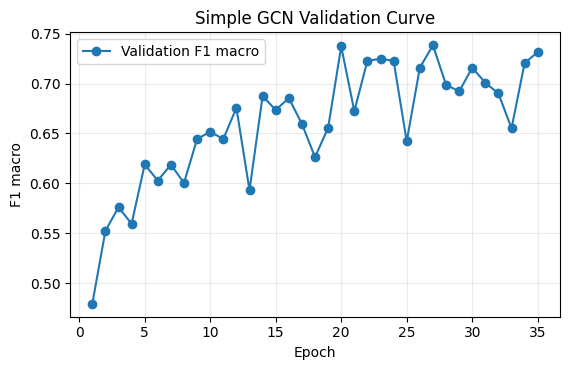

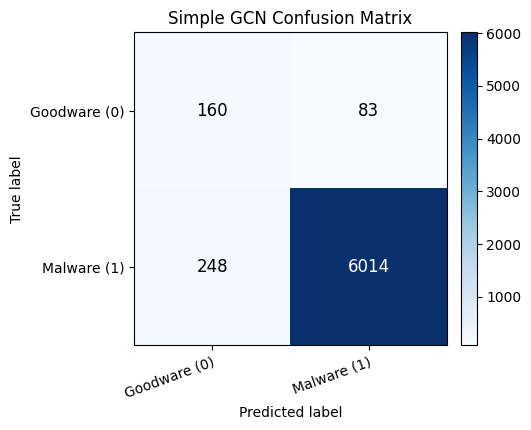

,precision,recall,f1-score,support
goodware_0,0.3922,0.6584,0.4916,243.0000
malware_1,0.9864,0.9604,0.9732,6262.0000
accuracy,0.9491,0.9491,0.9491,0.9491
macro avg,0.6893,0.8094,0.7324,6505.0000
weighted avg,0.9642,0.9491,0.9552,6505.0000


[I 2026-06-13 15:52:57,663] A new study created in memory with name: no-name-1f7d0796-61b8-46ba-b62b-2c6f8765e8cc


Training sage GNN with Optuna on cuda.


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

GraphSAGE
Best params: {'embedding_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.0027610585618011996, 'lr': 0.0010471209213501688, 'weight_decay': 0.0006720930050156114, 'batch_size': 128, 'aggregation': 'mean', 'heads': 1}
Best validation F1 macro: 0.8244


,number,value,params_aggregation,params_batch_size,params_dropout,params_embedding_dim,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,4,0.8259,mean,128,0.0028,32,256,0.0010,2,0.0007,COMPLETE
1,0,0.8014,max,64,0.3006,32,64,0.0006,3,0.0000,COMPLETE
2,2,0.8000,max,64,0.0610,64,64,0.0002,2,0.0000,COMPLETE
3,8,0.7806,mean,64,0.2594,32,256,0.0006,2,0.0000,COMPLETE
4,1,0.7666,mean,128,0.2280,32,128,0.0009,3,0.0000,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
21,22,0.0525,0.7411,0.8143
22,23,0.0472,1.0600,0.8193
23,24,0.0504,0.8857,0.8208
24,25,0.0456,0.8552,0.7950
25,26,0.0528,1.0105,0.8243


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9702,0.8302,0.7873,0.8302,0.8071,0.6298,0.9845


,pred_goodware_0,pred_malware_1
true_goodware_0,165,78
true_malware_1,116,6146


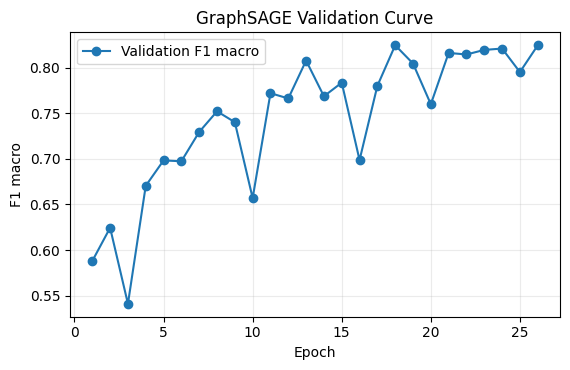

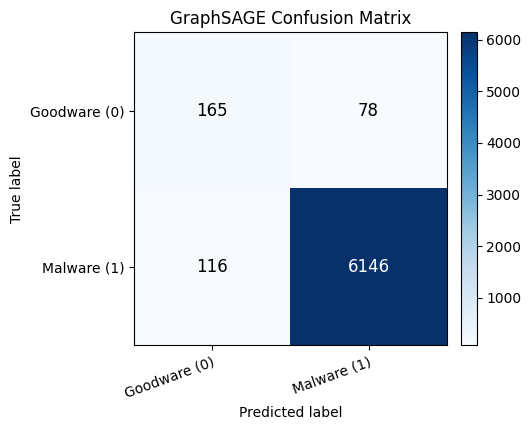

,precision,recall,f1-score,support
goodware_0,0.5872,0.6790,0.6298,243.0000
malware_1,0.9875,0.9815,0.9845,6262.0000
accuracy,0.9702,0.9702,0.9702,0.9702
macro avg,0.7873,0.8302,0.8071,6505.0000
weighted avg,0.9725,0.9702,0.9712,6505.0000


[I 2026-06-13 15:58:36,416] A new study created in memory with name: no-name-ce744f4a-6964-4b77-a3bf-9fc7ddc6602a


Training gat GNN with Optuna on cuda.


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` 

GAT
Best params: {'embedding_dim': 32, 'hidden_dim': 256, 'num_layers': 2, 'dropout': 0.0027610585618011996, 'lr': 0.0010471209213501688, 'weight_decay': 0.0006720930050156114, 'batch_size': 128, 'heads': 2, 'aggregation': 'mean'}
Best validation F1 macro: 0.8253


,number,value,params_batch_size,params_dropout,params_embedding_dim,params_heads,params_hidden_dim,params_lr,params_num_layers,params_weight_decay,state
0,4,0.8115,128,0.0028,32,2,256,0.0010,2,0.0007,COMPLETE
1,2,0.7758,64,0.0610,64,4,64,0.0002,2,0.0000,COMPLETE
2,8,0.7068,64,0.2594,32,2,256,0.0006,2,0.0000,COMPLETE
3,0,0.6672,64,0.3006,32,4,64,0.0006,3,0.0000,COMPLETE
4,9,0.6450,256,0.0724,64,4,64,0.0002,2,0.0088,COMPLETE


,epoch,train_loss,val_loss,val_f1_macro
37,38,0.0322,1.7203,0.8246
38,39,0.0321,2.0118,0.8193
39,40,0.0312,2.4442,0.8153
40,41,0.0612,1.6582,0.7872
41,42,0.0358,1.5199,0.8244


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_goodware_0,f1_malware_1
0,0.9736,0.7667,0.8332,0.7667,0.7959,0.6055,0.9863


,pred_goodware_0,pred_malware_1
true_goodware_0,132,111
true_malware_1,61,6201


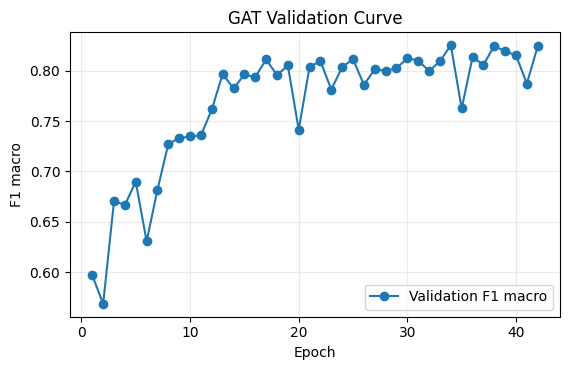

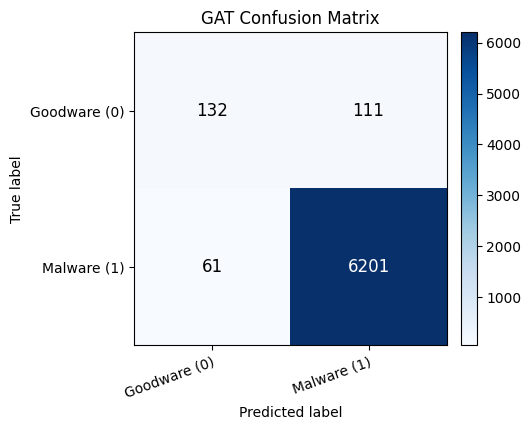

,precision,recall,f1-score,support
goodware_0,0.6839,0.5432,0.6055,243.0000
malware_1,0.9824,0.9903,0.9863,6262.0000
accuracy,0.9736,0.9736,0.9736,0.9736
macro avg,0.8332,0.7667,0.7959,6505.0000
weighted avg,0.9713,0.9736,0.9721,6505.0000


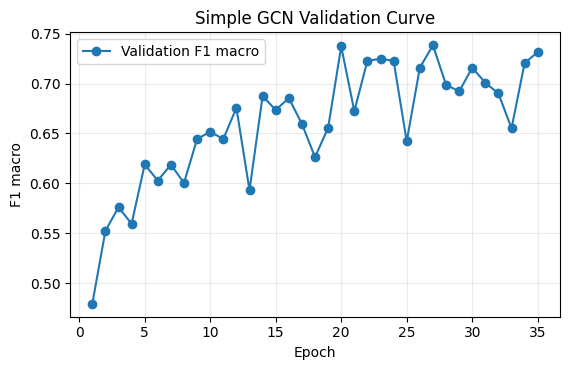

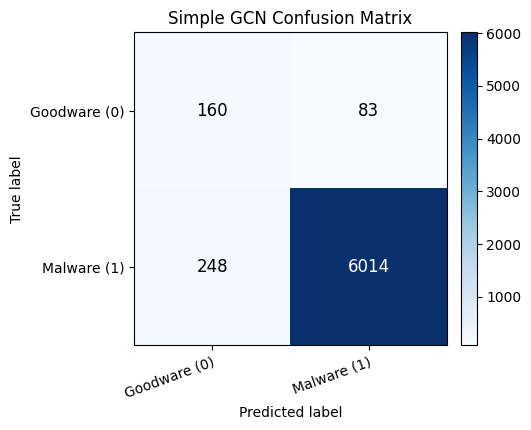

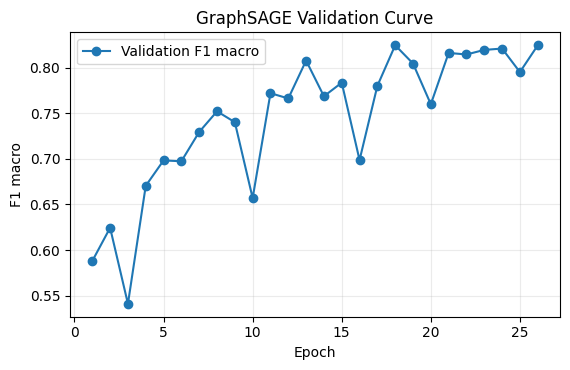

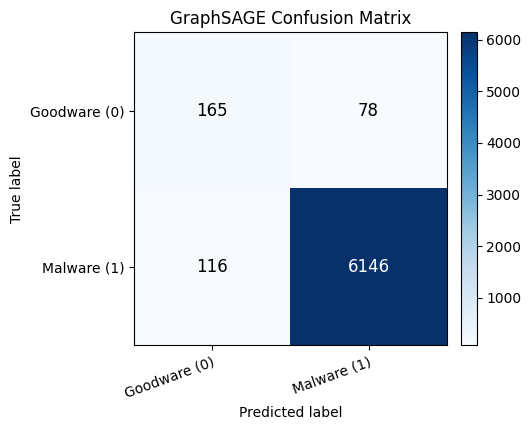

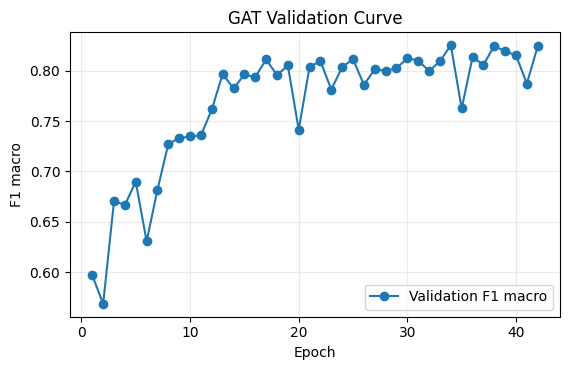

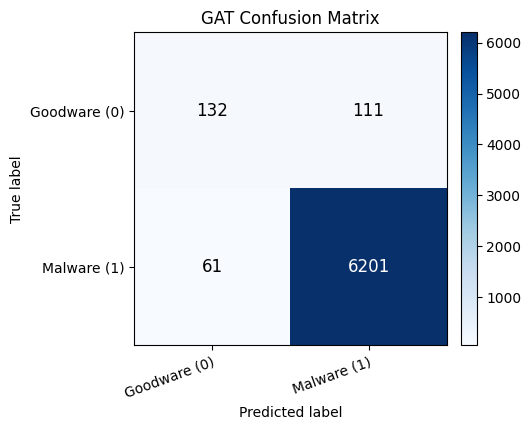

In [43]:
gnn_model_specs = {
    "gcn": "Simple GCN",
    "sage": "GraphSAGE",
    "gat": "GAT",
}
gnn_results = {}

for model_kind, model_label in gnn_model_specs.items():
    trained_model, config, best_params, best_score, trials, history = train_or_load_gnn(
        model_kind, X_train, y_train, api_to_id, len(api_to_id), n_trials=10, optuna_epochs=25, final_epochs=50
    )
    batch_size = best_params["batch_size"]
    _, _, test_loader, _ = make_gnn_loaders(X_train, y_train, X_test, y_test, api_to_id, batch_size=batch_size)
    metrics, cm, report = evaluate_gnn_classifier(trained_model, test_loader)
    save_gnn_artifacts(model_kind, trained_model, config, best_params, best_score, trials, history, metrics, cm, report)
    fig_curve = save_task4_training_curve_plot(history, model_label, f"{model_kind}_training_curve")
    fig_cm = save_task4_confusion_matrix_plot(cm, model_label, f"{model_kind}_confusion_matrix")
    gnn_results[model_kind] = {
        "label": model_label,
        "model": trained_model,
        "config": config,
        "best_params": best_params,
        "best_score": best_score,
        "trials": trials,
        "history": history,
        "metrics": metrics,
        "cm": cm,
        "report": report,
        "fig_curve": fig_curve,
        "fig_cm": fig_cm,
    }
    print(model_label)
    print("Best params:", best_params)
    print(f"Best validation F1 macro: {best_score:.4f}")
    display(trials.head(5).round(4))
    display(history.tail().round(4))
    display(metrics)
    display(cm)
    display(fig_curve)
    display(fig_cm)
    display(report)


,model,best_val_f1_macro,accuracy,balanced_accuracy,f1_macro,f1_goodware_0,f1_malware_1
0,Simple GCN,0.7384,0.9491,0.8094,0.7324,0.4916,0.9732
1,GraphSAGE,0.8244,0.9702,0.8302,0.8071,0.6298,0.9845
2,GAT,0.8253,0.9736,0.7667,0.7959,0.6055,0.9863


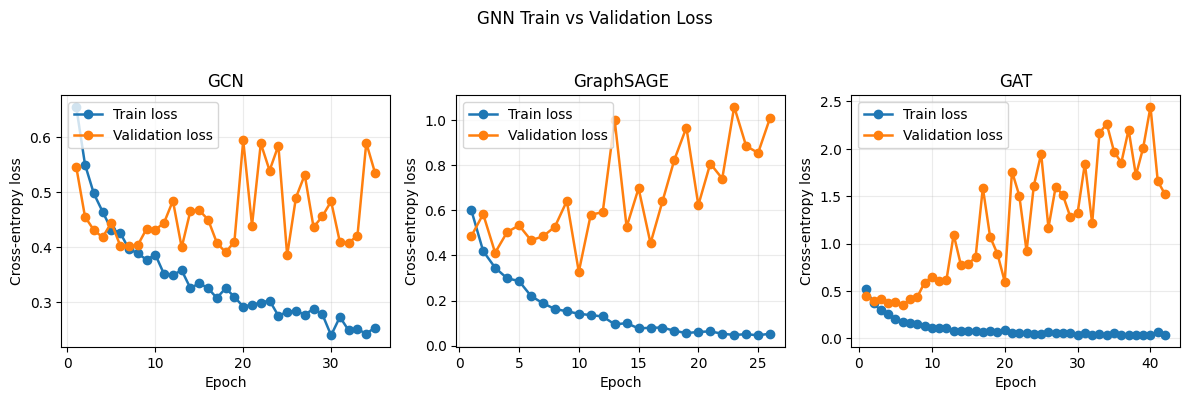

,Question,Answer
0,Model comparison,"Compare GCN, GraphSAGE and GAT against the Tas..."


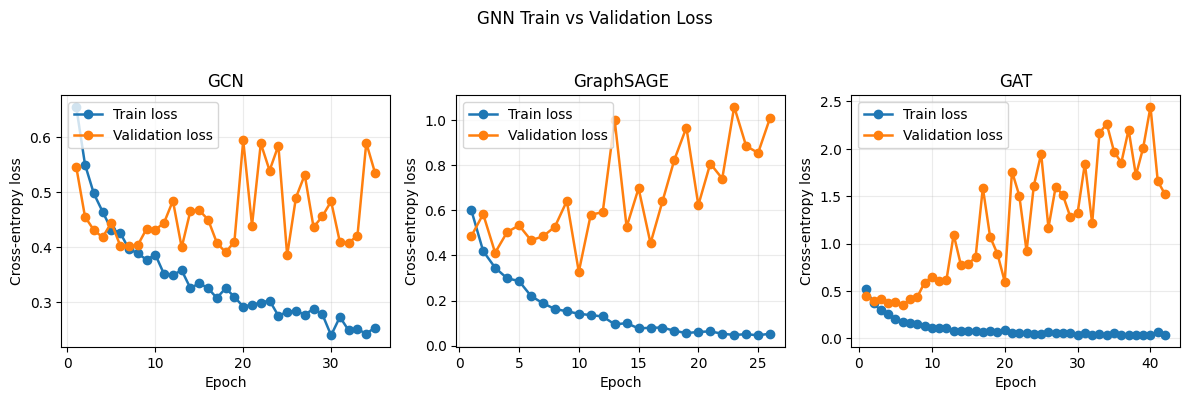

In [44]:
gnn_comparison = pd.concat([
    result["metrics"].assign(model=result["label"], best_val_f1_macro=result["best_score"])
    for result in gnn_results.values()
], ignore_index=True)
cols = ["model", "best_val_f1_macro", "accuracy", "balanced_accuracy", "f1_macro", "f1_goodware_0", "f1_malware_1"]
display(gnn_comparison[cols].round(4))

fig = save_task4_loss_curves_plot(gnn_results)
display(fig)

task4_answers = [
    ["Model comparison", "Compare GCN, GraphSAGE and GAT against the Task 1 Logistic Regression baseline and the previous neural architectures using macro F1 and goodware F1."],
]
display(pd.DataFrame(task4_answers, columns=["Question", "Answer"]))
